# 14 - Run VAE Pipeline

This notebook loads preprocessed stellar spectra, trains a Variational Autoencoder (VAE), and analyzes its latent space.

It supports selecting which orders to use (RV-corrected or not and how preprocessed) and visualizes both training and latent results. 

Many different options to train the VAE.

We are not aiming for for RV/SNR/etc. correlation - especially not SNR (because this only tells us to what extend we encode instrumental quality).

Instead, we want the latent space to capture stellar surface asymmetries - e.g., distortions caused by spots, plages, or other magnetic activity.

This means if our UMAP plots don't correlate with SNR, RV, FWHM, etc., that may be good as long as we are able to see that the latent space encodes shape changes of the lines, so that they follow the stellar rotation period (BJD/Phase). However, we will not be able to observe any fine grained spectral changes if the reconstruction is not almsot perfect.

**Goal:** Learn unsupervised features of the average spectral line shape. Ideally we want to track how those shapes vary with rotation, which reflects stellar surface activity.

### 1. Setup and Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle

from sklearn.preprocessing import StandardScaler
from src.data.loader import select_orders
from src.models.vae_model import SimpleConvVAE1D, FullConvVAE1D, UNetVAE1D
from src.models.training import build_callbacks, augment_with_noise, compute_noise_weights
from src.models.utils import save_all_models
from src.analysis.visualization import plot_training_loss, plot_reconstruction, plot_order_reconstructions
from src.analysis.latent_analysis import plot_umap, plot_pca, plot_tsne, plot_lomb_scargle

from src.data.loader import load_file_list, load_metadata
from astropy.io import fits

from numba import cuda
import gc

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

2025-06-23 18:34:01.331637: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-23 18:34:01.366762: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-23 18:34:01.366798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-23 18:34:01.367809: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-23 18:34:01.373341: I tensorflow/core/platform/cpu_feature_guar

In [2]:
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### 2. Reproducibility and Config

In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.config.experimental.enable_op_determinism()

### 3. Load Metadata and Preprocessed Spectra

In [4]:
meta = load_metadata()

Full Spectra (when using entire orders):

In [5]:
with open("../outputs/preprocessed/with_rv_unit.pkl", "rb") as f:
    with_rv_unit = pickle.load(f)
with open("../outputs/preprocessed/with_rv_var.pkl", "rb") as f:
    with_rv_var = pickle.load(f)
with open("../outputs/preprocessed/with_rv_raw.pkl", "rb") as f:
    with_rv_raw = pickle.load(f)

with open("../outputs/preprocessed/without_rv_unit.pkl", "rb") as f:
    without_rv_unit = pickle.load(f)
with open("../outputs/preprocessed/without_rv_var.pkl", "rb") as f:
    without_rv_var = pickle.load(f)
with open("../outputs/preprocessed/without_rv_raw.pkl", "rb") as f:
    without_rv_raw = pickle.load(f)

Cropped order 32:

In [6]:
with open("../outputs/preprocessed/cropped_order32/with_rv_unit.pkl", "rb") as f:
    data = pickle.load(f)
    with_rv_unit_32 = data["spectra"]
    wavelengths_32 = data["wavelengths"]

with open("../outputs/preprocessed/cropped_order32/with_rv_var.pkl", "rb") as f:
    data = pickle.load(f)
    with_rv_var_32 = data["spectra"]

with open("../outputs/preprocessed/cropped_order32/with_rv_raw.pkl", "rb") as f:
    data = pickle.load(f)
    with_rv_raw_32 = data["spectra"]

with open("../outputs/preprocessed/cropped_order32/without_rv_unit.pkl", "rb") as f:
    data = pickle.load(f)
    without_rv_unit_32 = data["spectra"]

with open("../outputs/preprocessed/cropped_order32/without_rv_var.pkl", "rb") as f:
    data = pickle.load(f)
    without_rv_var_32 = data["spectra"]

with open("../outputs/preprocessed/cropped_order32/without_rv_raw.pkl", "rb") as f:
    data = pickle.load(f)
    without_rv_raw_32 = data["spectra"]

### 4. Select Input for VAE Training

Define orders and processing mode:

In [7]:
VALID_ORDERS = list(range(17, 39))
ORDER_SELECTION = [32]
USE_RV_SHIFTED = True
USE_UNIT_VARIANCE = True
USE_SUBTRACT_MEAN = True
USE_CROPPED_ORDER = True
CROPPING_RANGE = (7137.0, 7140.53)
UPSAMPLE_FACTOR = 1

Select the appropriate spectra based on settings:

In [8]:
if USE_CROPPED_ORDER:
    if USE_RV_SHIFTED:
        if USE_SUBTRACT_MEAN:
            processed_orders = with_rv_unit_32 if USE_UNIT_VARIANCE else with_rv_var_32
        else:
            processed_orders = with_rv_raw_32
    else:
        if USE_SUBTRACT_MEAN:
            processed_orders = without_rv_unit_32 if USE_UNIT_VARIANCE else without_rv_var_32
        else:
            processed_orders = without_rv_raw_32
else:
    if USE_RV_SHIFTED:
        if USE_SUBTRACT_MEAN:
            processed_orders = with_rv_unit if USE_UNIT_VARIANCE else with_rv_var
        else:
            processed_orders = with_rv_raw
    else:
        if USE_SUBTRACT_MEAN:
            processed_orders = without_rv_unit if USE_UNIT_VARIANCE else without_rv_var
        else:
            processed_orders = without_rv_raw

X = select_orders(processed_orders, ORDER_SELECTION)

#### **Adding noise for Data Augmentation**

In [9]:
variation_per_pixel = np.std(X, axis=0)

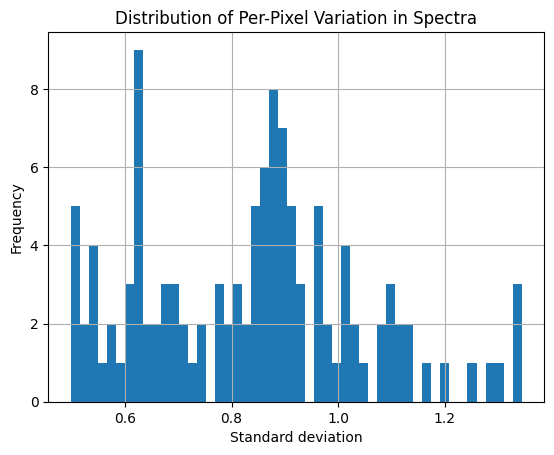

In [10]:
plt.hist(variation_per_pixel, bins=50)
plt.title("Distribution of Per-Pixel Variation in Spectra")
plt.xlabel("Standard deviation")
plt.ylabel("Frequency")
plt.grid(True)

Load the mask:

In [11]:
mask_path = "../../aumicAE/data/masks/CARM_VIS_M15.mas"
mask_df = pd.read_csv(mask_path, delim_whitespace=True, comment="#", header=None,
                      names=["lambda", "weight", "element"])
mask_lines = mask_df["lambda"].values 

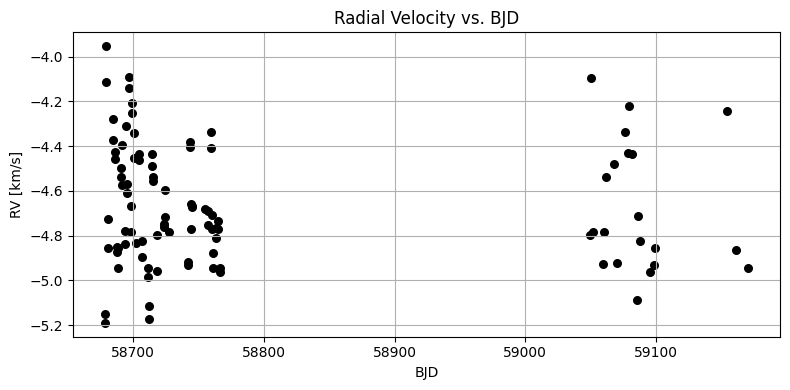

In [12]:
plt.figure(figsize=(8, 4))
plt.scatter(meta["BJD"], meta["RV"], color="black", s=30)
plt.xlabel("BJD")
plt.ylabel("RV [km/s]")
plt.title("Radial Velocity vs. BJD")
plt.grid(True)
plt.tight_layout()
plt.show()

**Data Augmentation Options:**

NOISE_FACTOR is how much more observations we use than originally.

MIN_WEIGHT is the minimum noise level (even right at the mask lines).

SIGMA_PROTECT determines how for a point must be from the mask line for full noise (the noise is decreasing slowly the closer to the line, e.g., with SIGMA_PROTECT = 0.05, we reach ~95% noise level about 0.12 Å away from a mask line.)

In [13]:
NOISE_STD = 0.2
NOISE_FACTOR = 15
USE_NOISE = True
PROTECT_LINES = True
SIGMA_PROTECT = 0.07
MIN_WEIGHT = 0.02

Get the wavelength grid:

In [14]:
if PROTECT_LINES:
    if USE_CROPPED_ORDER:
        with open("../outputs/preprocessed/cropped_order32/with_rv_unit.pkl", "rb") as f:
            data = pickle.load(f)
            wavelengths_dict = data["wavelengths"]
            wavelengths_stacked = np.hstack([wavelengths_dict[o] for o in ORDER_SELECTION])
            wavelengths = wavelengths_stacked
    else:
        raise ValueError("Wavelength grid for non-cropped orders is not implemented yet, but required for line protection.")

Augmenting the data:

In [15]:
if USE_NOISE:
    X_aug = augment_with_noise(
        X,
        factor=NOISE_FACTOR,
        noise_std=NOISE_STD,
        wavelengths=wavelengths,
        mask_lines=mask_lines,
        sigma_protect=SIGMA_PROTECT,
        protect_mask_lines=PROTECT_LINES,
        min_weight=MIN_WEIGHT
    )
else:
    X_aug = X

#### **Normalize input to zero mean, unit standard deviation**

In [16]:
scaler = StandardScaler()
X_scaled_original = scaler.fit_transform(X)
X_scaled = scaler.transform(X_aug)

### 5. Build and Compile VAE

(Note: The SimpleVAE1D is not necessary here anymore, we just keep it to have the architecture used for training the early models.)

In [17]:
VAE_MODEL = "FullConvVAE1D" 
USE_DENOISING = True 
LATENT_DIM = 16
CONV_FILTERS = (32, 64)
KERNEL_SIZE = 3
ACTFN = "relu"
LEARNING_RATE = 1e-5
BATCH_SIZE = 95
EPOCHS = 5000
BETA_VAR = tf.Variable(0.0, trainable=True)
BETA_MAX = 1e-5
DROPOUT = 0.0
PATIENCE = 20
WARMUP = True
RESIDUAL_BLOCK = True
DENSE_ENCODER = True
DENSE_UNITS_ENCODER = 128
DENSE_DECODER = True
DENSE_UNITS_DECODER = 128
MODEL_VERSION = "43"

if USE_DENOISING:
    X_clean_repeated = np.repeat(X_scaled_original, repeats=(X_scaled.shape[0] // X_scaled_original.shape[0]), axis=0)
    train_targets = X_clean_repeated
else:
    train_targets = X_scaled

print("Input shape:", X_scaled.shape)

Input shape: (1520, 118)


In [18]:
if VAE_MODEL == "FullConvVAE1D":
    vae_model = FullConvVAE1D(
        input_dim=X.shape[1],
        latent_dim=LATENT_DIM,
        actfn=ACTFN,
        beta=BETA_VAR,
        dropout_rate=DROPOUT,
        conv_filters=CONV_FILTERS,
        kernel_size=KERNEL_SIZE,
        use_residual=RESIDUAL_BLOCK,
        use_dense_encoder=DENSE_ENCODER,
        dense_units_encoder=DENSE_UNITS_ENCODER,
        use_dense_decoder=DENSE_DECODER,
        dense_units_decoder=DENSE_UNITS_DECODER
    )
elif VAE_MODEL == "UNetVAE1D":
    vae_model = UNetVAE1D(
        input_dim=X.shape[1],
        latent_dim=LATENT_DIM,
        actfn=ACTFN,
        beta=BETA_VAR,
        dropout_rate=DROPOUT,
        conv_filters=CONV_FILTERS,
        kernel_size=KERNEL_SIZE
    )
else:
    raise ValueError(f"Unknown VAE model: {VAE_MODEL}")

vae, encoder, decoder = vae_model.model_tf()
vae.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE))

callbacks = build_callbacks(
    beta_var=BETA_VAR,
    max_beta=BETA_MAX,
    n_epochs=EPOCHS,
    patience=PATIENCE,
    warmup=WARMUP
)

### 6. Train VAE

In [19]:
history = vae.fit(
    X_scaled, train_targets,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/5000


2025-06-23 18:34:11.374958: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
2025-06-23 18:34:11.849552: I external/local_xla/xla/service/service.cc:168] XLA service 0x7df6ecef5040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-06-23 18:34:11.849577: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-06-23 18:34:11.858591: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1750696451.930627    8590 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


16/16 [==============================] - 5s 7ms/step - loss: 1.0201 - lr: 1.0000e-05
Epoch 2/5000
16/16 [==============================] - 0s 6ms/step - loss: 1.0180 - lr: 1.0000e-05
Epoch 3/5000
16/16 [==============================] - 0s 8ms/step - loss: 1.0152 - lr: 1.0000e-05
Epoch 4/5000
16/16 [==============================] - 0s 10ms/step - loss: 1.0134 - lr: 1.0000e-05
Epoch 5/5000
16/16 [==============================] - 0s 6ms/step - loss: 1.0104 - lr: 1.0000e-05
Epoch 6/5000
16/16 [==============================] - 0s 6ms/step - loss: 1.0059 - lr: 1.0000e-05
Epoch 7/5000
16/16 [==============================] - 0s 10ms/step - loss: 0.9982 - lr: 1.0000e-05
Epoch 8/5000
16/16 [==============================] - 0s 8ms/step - loss: 0.9857 - lr: 1.0000e-05
Epoch 9/5000
16/16 [==============================] - 0s 8ms/step - loss: 0.9675 - lr: 1.0000e-05
Epoch 10/5000
16/16 [==============================] - 0s 6ms/step - loss: 0.9433 - lr: 1.0000e-05
Epoch 11/5000
16/16 [=========

### 7. Save Loss Plot

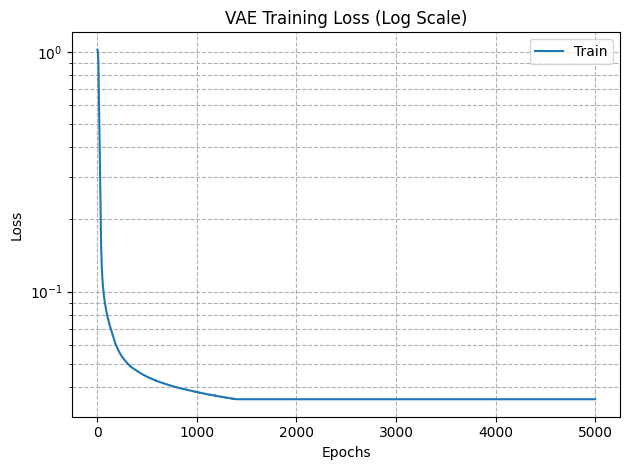

In [20]:
save_path = f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/loss/training_loss.png"
plot_training_loss(history, save_path=save_path)

### 8. Encode, Decode, and Save Models

In [21]:
if VAE_MODEL == "UNetVAE1D":
    encoder_z_mean = tf.keras.Model(encoder.input, encoder.get_layer("z_mean").output)
    encoder_z_log_sigma = tf.keras.Model(encoder.input, encoder.get_layer("z_log_sigma").output)
    encoder_skip = tf.keras.Model(encoder.input, encoder.get_layer("conv1_skip").output)

    z_mean = encoder_z_mean.predict(X_scaled_original)
    z_log_sigma = encoder_z_log_sigma.predict(X_scaled_original)
    skip = encoder_skip.predict(X_scaled_original)

    x_pred = decoder.predict([z_mean, skip])

else:  
    z_mean, z_log_sigma, z = encoder.predict(X_scaled_original)
    x_pred = decoder.predict(z)

3/3 [==============================] - 0s 6ms/step


In [22]:
settings = {
    "input_dim": int(X.shape[1]),
    "latent_dim": int(LATENT_DIM),
    "use_rv_shifted": USE_RV_SHIFTED,
    "use_unit_variance": USE_UNIT_VARIANCE,
    "selected_orders": ORDER_SELECTION,
    "use_subtract_mean": USE_SUBTRACT_MEAN,
    "use_cropped_order": USE_CROPPED_ORDER,
    "cropping_range": CROPPING_RANGE,
    "upsample_factor": UPSAMPLE_FACTOR,
    "model_type": VAE_MODEL,
    "model_version": MODEL_VERSION,
    "kernel_size": KERNEL_SIZE,
    "activation": ACTFN,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "beta_variable": float(BETA_VAR.numpy().item()),
    "beta_max": BETA_MAX,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "data_augmentation": USE_NOISE,
    "noise_std": NOISE_STD,
    "noise_factor": NOISE_FACTOR,
    "protectMaskLines": PROTECT_LINES,
    "sigma_protect": SIGMA_PROTECT,
    "min_weight": MIN_WEIGHT,
    "denoising": USE_DENOISING
}

if VAE_MODEL == "FullConvVAE1D":
    settings.update({
        "conv_filters": CONV_FILTERS,
        "use_residual": RESIDUAL_BLOCK,
        "use_dense_encoder": DENSE_ENCODER,
        "dense_units_encoder": DENSE_UNITS_ENCODER,
        "use_dense_decoder": DENSE_DECODER,
        "dense_units_decoder": DENSE_UNITS_DECODER
    })
elif VAE_MODEL == "UNetVAE1D":
    settings.update({
        "conv_filters": CONV_FILTERS
    })

In [23]:
save_all_models(vae, encoder, decoder, f"outputs/models/vae_full/v_{MODEL_VERSION}/", settings)

Models and config saved to: outputs/models/vae_full/v_43/*.keras


### 9. Analyze Latent Space (UMAP, PCA, TSNE)

**UMAP with various indicators**

First, we calculate the SNR mean for al the valid orders we are using:

In [24]:
snr_cols = [f"SNR_{o}" for o in ORDER_SELECTION if f"SNR_{o}" in meta.columns]
meta["SNR_mean"] = meta[snr_cols].mean(axis=1)

Next, we plot the UMAPs:

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


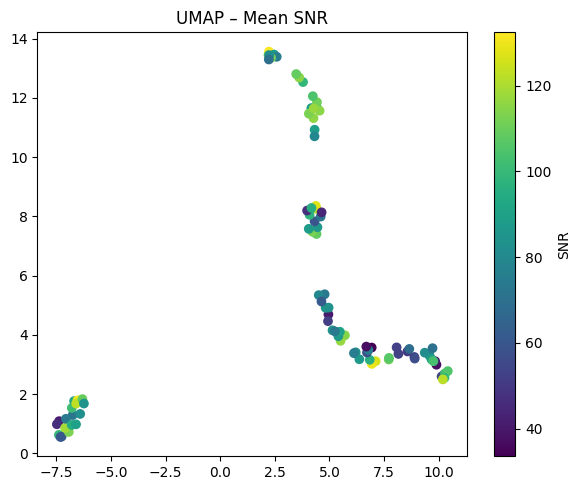

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


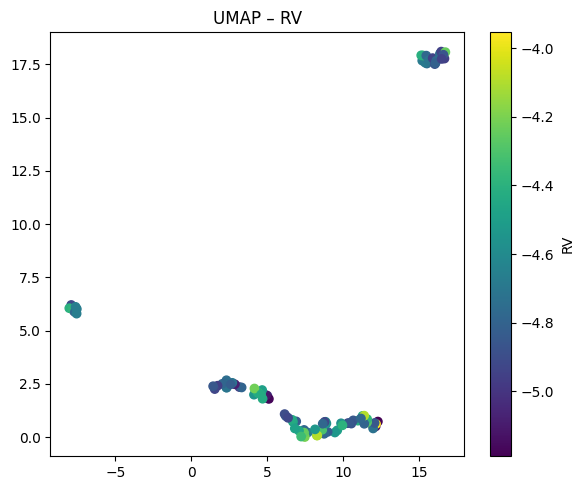

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


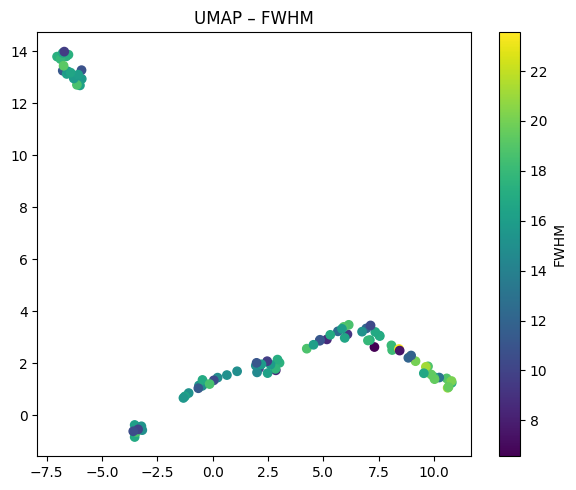

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


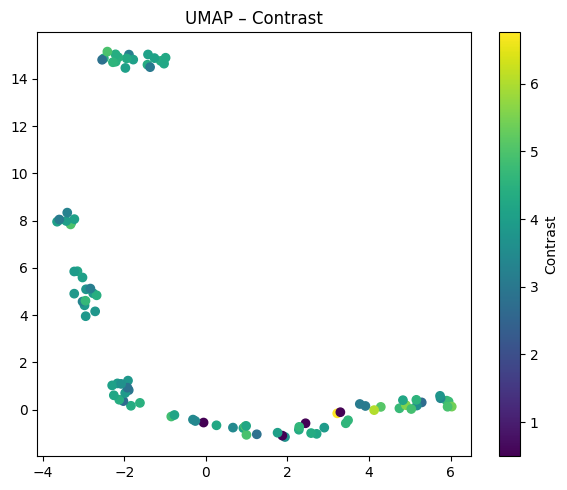

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


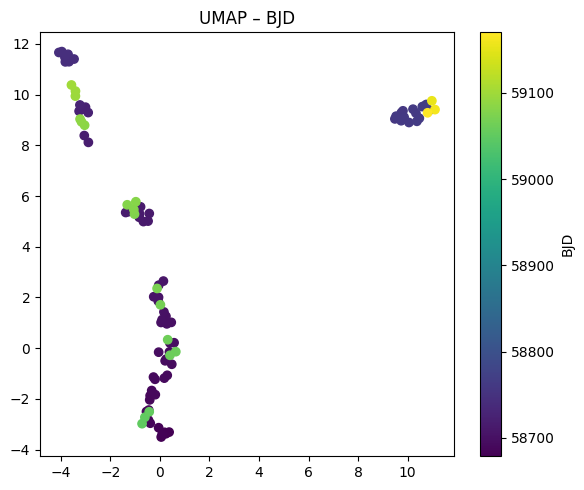

In [25]:
plot_umap(z_mean, meta["SNR_mean"], title="UMAP – Mean SNR", color_label="SNR",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/SNR_mean.png")

plot_umap(z_mean, meta["RV"], title="UMAP – RV", color_label="RV",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/RV.png")

plot_umap(z_mean, meta["FWHM"], title="UMAP – FWHM", color_label="FWHM",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/FWHM.png")

plot_umap(z_mean, meta["CONTRAST"], title="UMAP – Contrast", color_label="Contrast",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/Contrast.png")

plot_umap(z_mean, meta["BJD"], title="UMAP – BJD", color_label="BJD",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/BJD.png")

**Color Normalization by Observation Block**

Since the time gap creates imbalance in colormap, we normalize BJD within each campaign. 

First, we find the largest gap - we calculate the exact point split:

In [26]:
bjd_sorted = np.sort(meta["BJD"].values)

bjd_diffs = np.diff(bjd_sorted)

gap_index = np.argmax(bjd_diffs)

split_bjd = bjd_sorted[gap_index + 1]

print(f"Largest gap at BJD = {split_bjd:.2f} (gap = {bjd_diffs[gap_index]:.2f} days)")

Largest gap at BJD = 59049.55 (gap = 283.21 days)


Split the observations into two blocks and rescale the BJD values within each block to the  range [0,1] independently:

In [27]:
mask_early = meta["BJD"] < split_bjd
mask_late = ~mask_early

meta["BJD_scaled"] = np.nan
meta.loc[mask_early, "BJD_scaled"] = (meta.loc[mask_early, "BJD"] - meta.loc[mask_early, "BJD"].min()) / \
                                     (meta.loc[mask_early, "BJD"].max() - meta.loc[mask_early, "BJD"].min())

meta.loc[mask_late, "BJD_scaled"] = (meta.loc[mask_late, "BJD"] - meta.loc[mask_late, "BJD"].min()) / \
                                    (meta.loc[mask_late, "BJD"].max() - meta.loc[mask_late, "BJD"].min())

UMAP coloring:

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


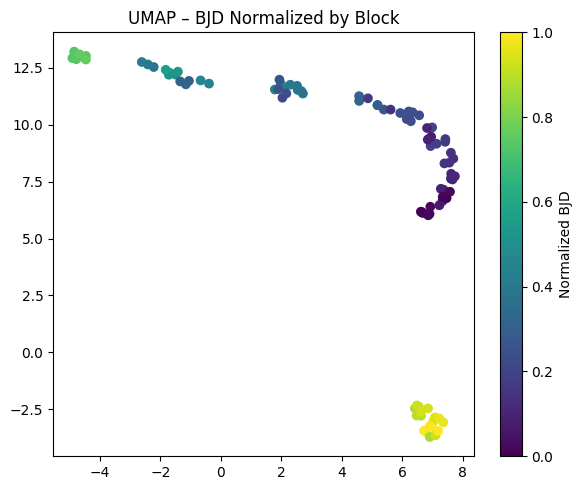

In [28]:
plot_umap(z_mean, meta["BJD_scaled"], title="UMAP – BJD Normalized by Block", color_label="Normalized BJD",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/BJD_blocknorm.png")

**Scaled to the Length of each Block**

(Note that we also tried to take exact rotation periods into account, however, we did not have any good results with this.)

In [29]:
early_start = meta.loc[mask_early, "BJD"].min()
early_end = meta.loc[mask_early, "BJD"].max()
late_start = meta.loc[mask_late, "BJD"].min()
late_end = meta.loc[mask_late, "BJD"].max()

duration_early = early_end - early_start
duration_late = late_end - late_start
gap_between_blocks = late_start - early_start

print(f"Early block: {duration_early:.2f} days")
print(f"Late block: {duration_late:.2f} days")
print(f"Gap between start of blocks: {gap_between_blocks:.2f} days")

Early block: 87.77 days
Late block: 120.71 days
Gap between start of blocks: 370.98 days


In [30]:
T_early = early_end - early_start
T_late = late_end - late_start
T_max = max(T_early, T_late)

T_short = min(T_early, T_late)
padding_fraction = (1 - (T_short / T_max)) / 2

if T_early < T_late:
    early_range = (padding_fraction, 1 - padding_fraction)
    late_range = (0, 1)
else:
    early_range = (0, 1)
    late_range = (padding_fraction, 1 - padding_fraction)

meta["BJD_scaled"] = np.nan

meta.loc[mask_early, "BJD_scaled"] = early_range[0] + (
    (meta.loc[mask_early, "BJD"] - early_start) / T_early
) * (early_range[1] - early_range[0])

meta.loc[mask_late, "BJD_scaled"] = late_range[0] + (
    (meta.loc[mask_late, "BJD"] - late_start) / T_late
) * (late_range[1] - late_range[0])

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


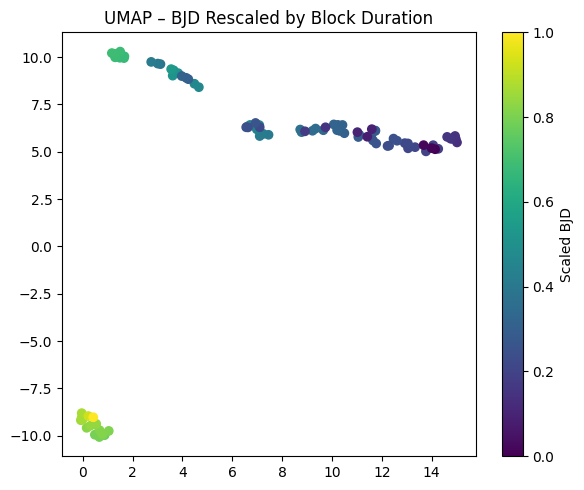

In [31]:
plot_umap(z_mean, meta["BJD_scaled"],
          title="UMAP – BJD Rescaled by Block Duration",
          color_label="Scaled BJD",
          save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/UMAP/BJD_rescaled_duration.png")

**Latent Dimensions vs. BJD:**

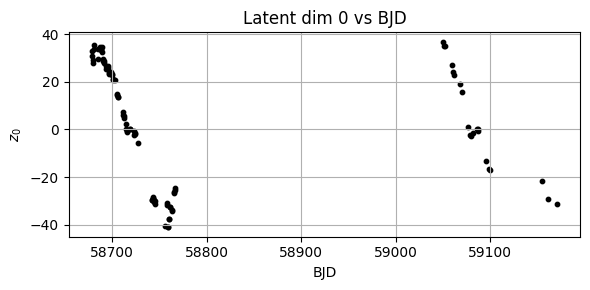

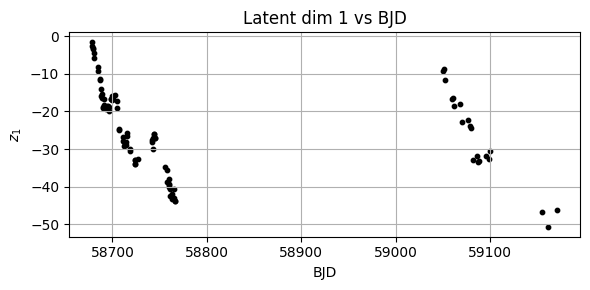

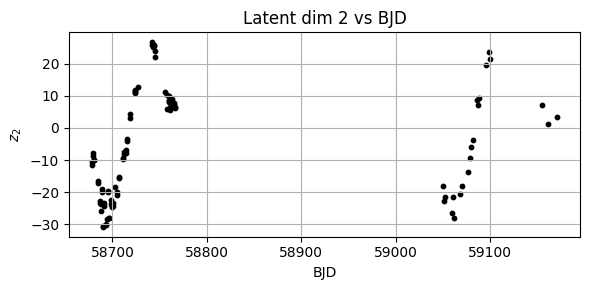

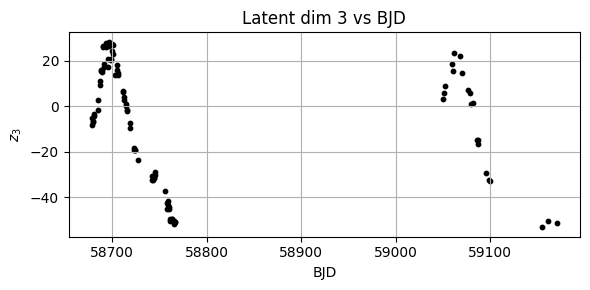

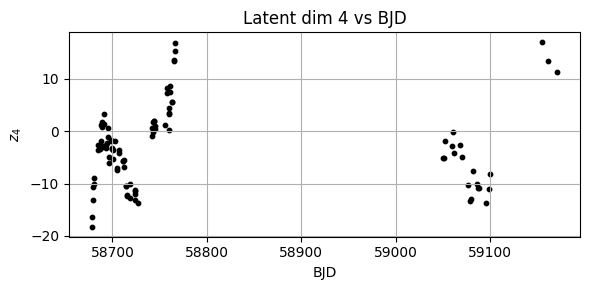

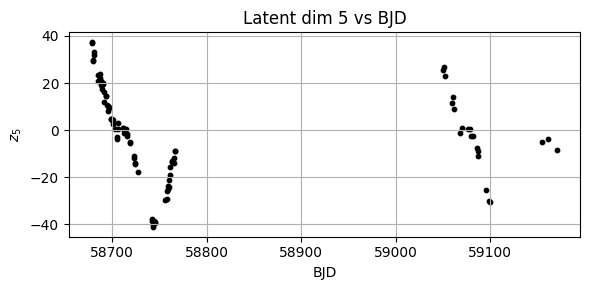

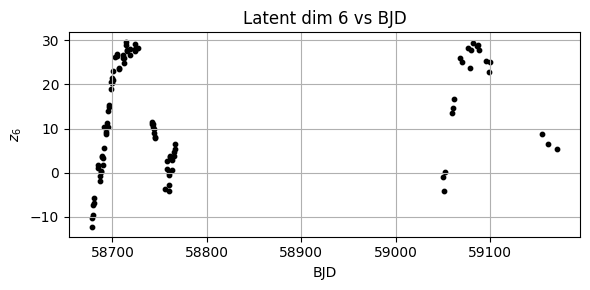

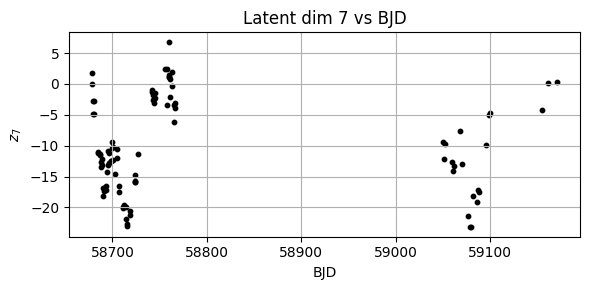

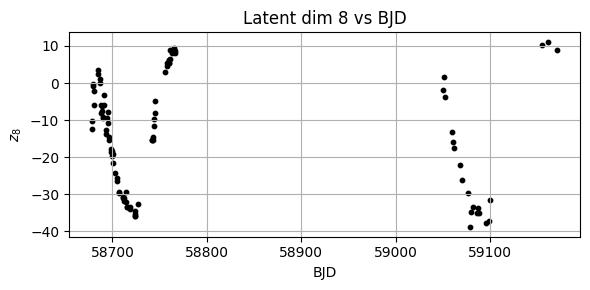

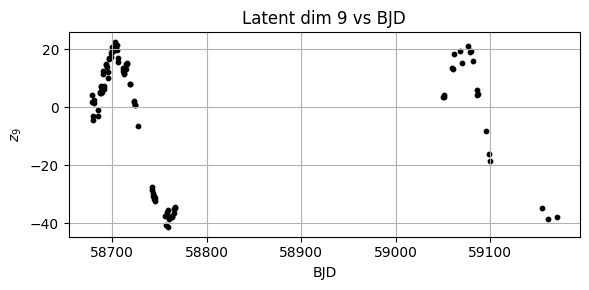

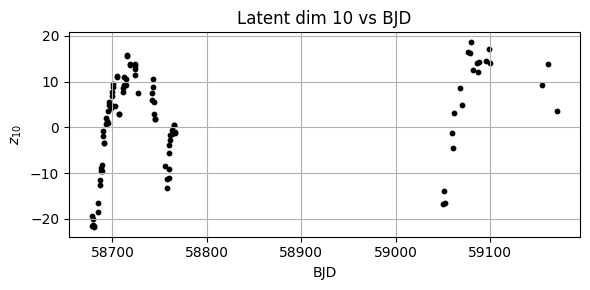

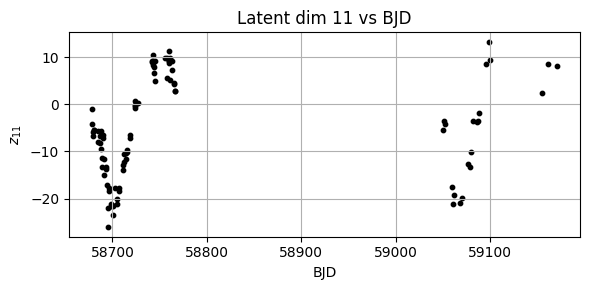

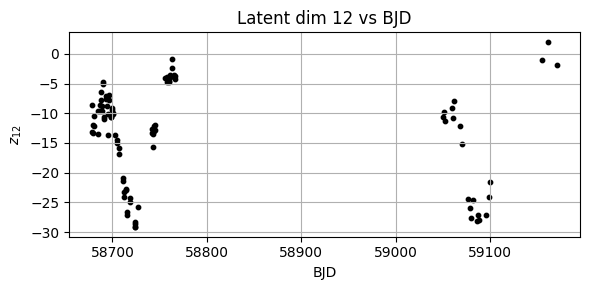

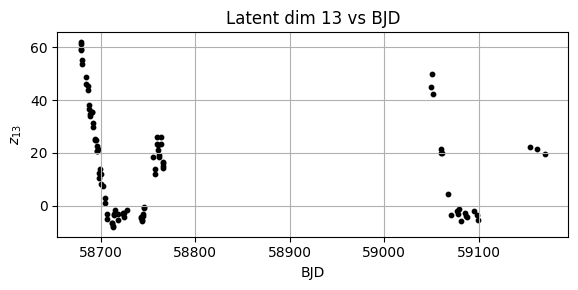

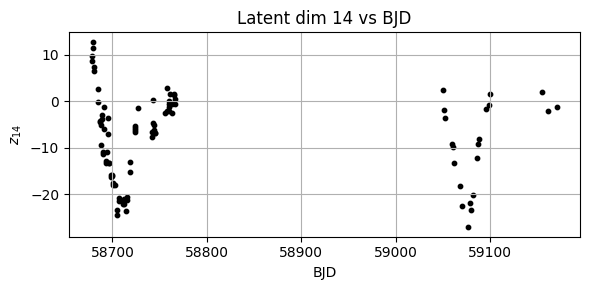

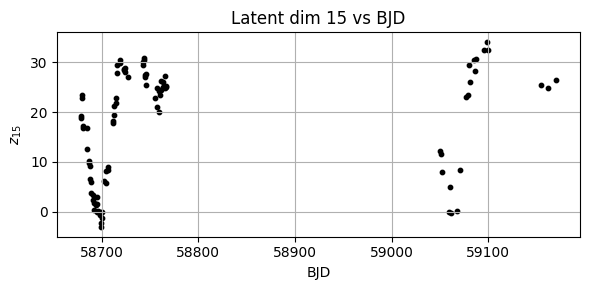

In [32]:
plot_dir = f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/ZdimvsBJD"
os.makedirs(plot_dir, exist_ok=True)

n_dims = z_mean.shape[1]

for i in range(n_dims):
    plt.figure(figsize=(6, 3))
    plt.scatter(meta["BJD"], z_mean[:, i], c="black", s=10)
    plt.title(f"Latent dim {i} vs BJD")
    plt.xlabel("BJD")
    plt.ylabel(f"$z_{{{i}}}$")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{plot_dir}/zdim_{i}_vs_BJD.png")
    plt.show()
    plt.close()

Confirm uniqueness:

In [33]:
meta["BJD"].value_counts().sort_values(ascending=False).head()

58678.564887    1
58696.520041    1
58679.534116    1
58679.538856    1
58680.529519    1
Name: BJD, dtype: int64

In [34]:
meta["BJD"].nunique()

95

In [35]:
meta["RV"].nunique()

95

**PCA and t-SNE:**

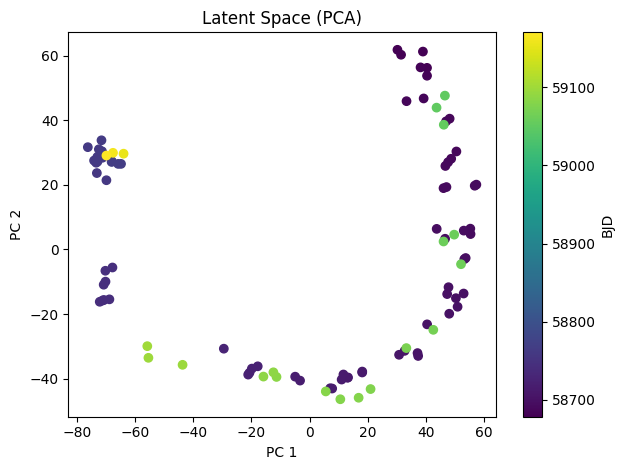

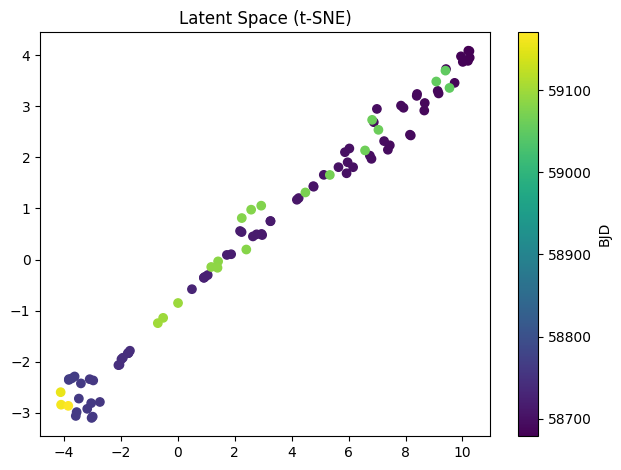

In [36]:
plot_pca(z_mean, meta["BJD"], title="Latent Space (PCA)", color_label="BJD",
            save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/PCA/BJD.png")
plot_tsne(z_mean, meta["BJD"], title="Latent Space (t-SNE)", color_label="BJD",
            save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/tSNE/BJD.png")

### 10. Lomb-Scargle Periodograms

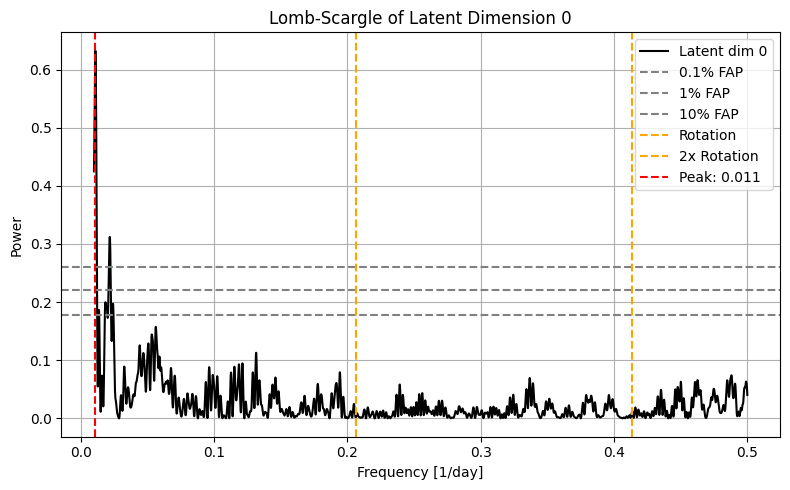

Latent dim 0: Best period = 90.267 days


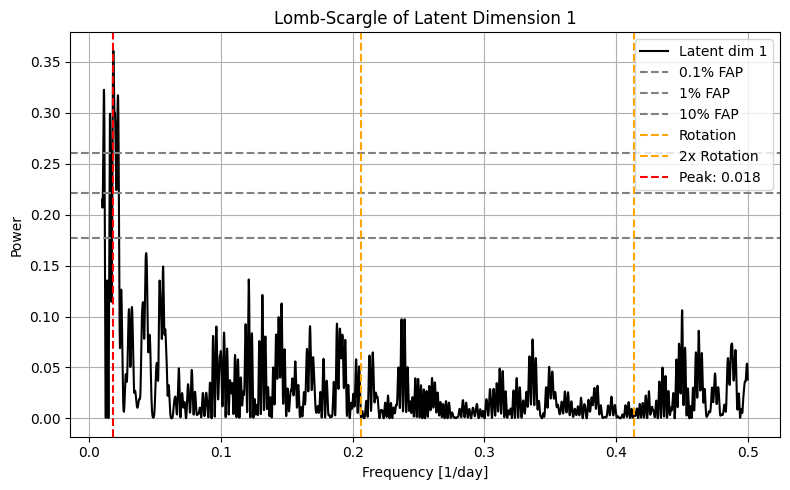

Latent dim 1: Best period = 54.550 days


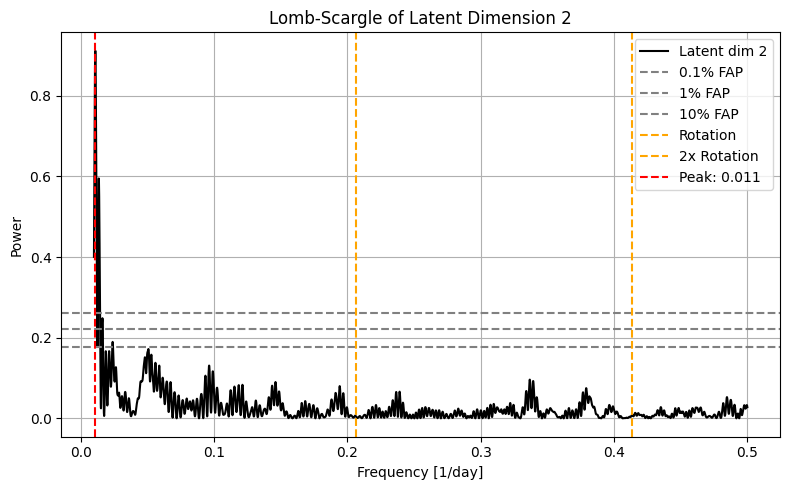

Latent dim 2: Best period = 91.073 days


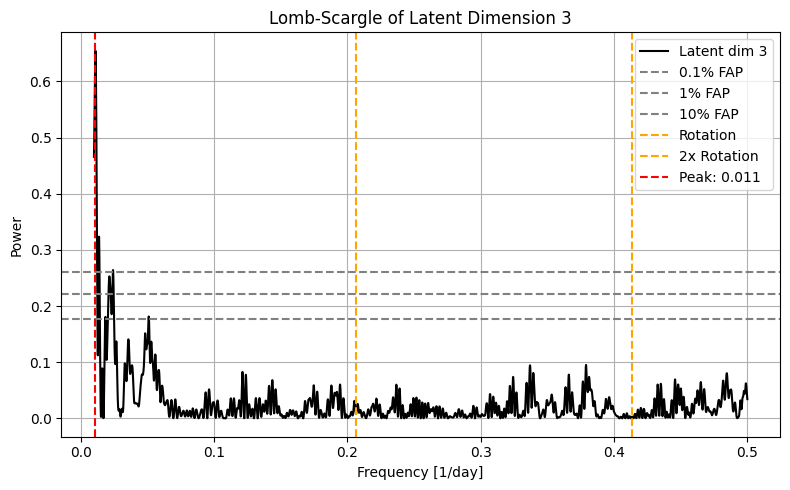

Latent dim 3: Best period = 90.267 days


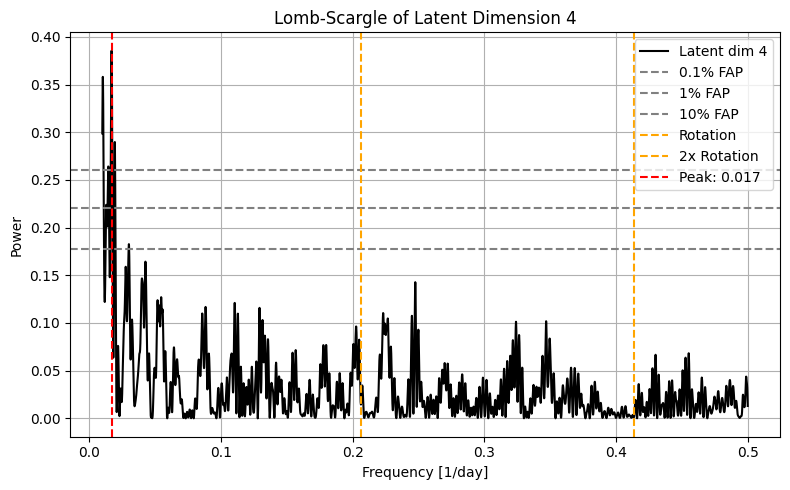

Latent dim 4: Best period = 58.626 days


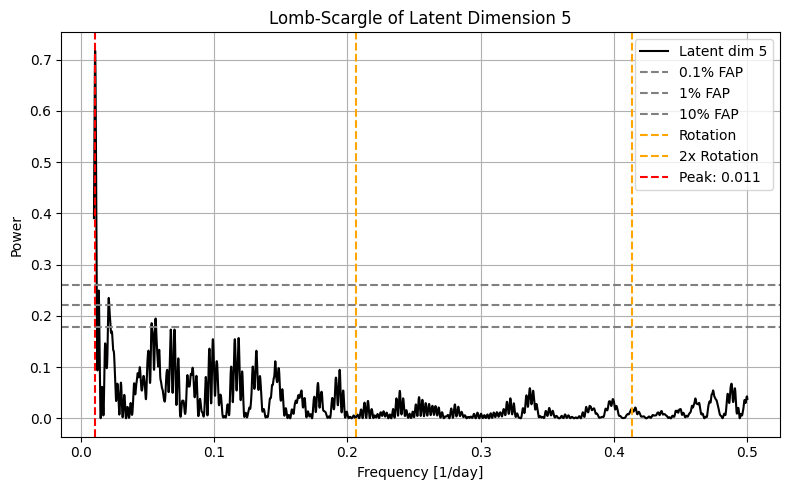

Latent dim 5: Best period = 91.893 days


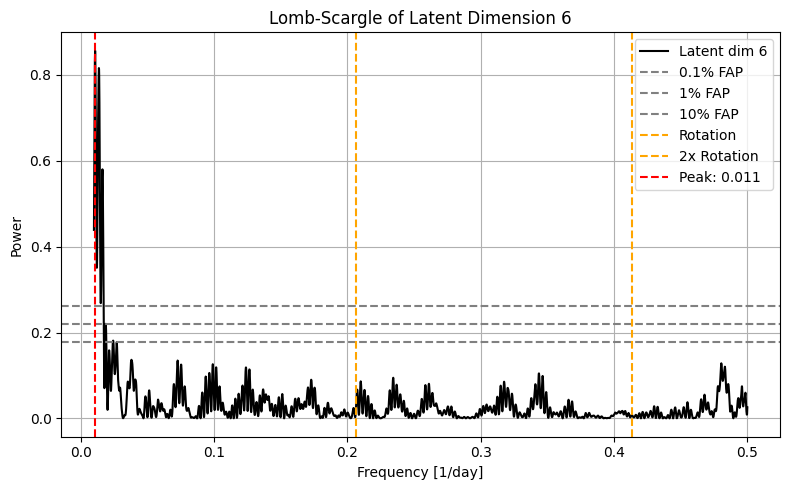

Latent dim 6: Best period = 91.893 days


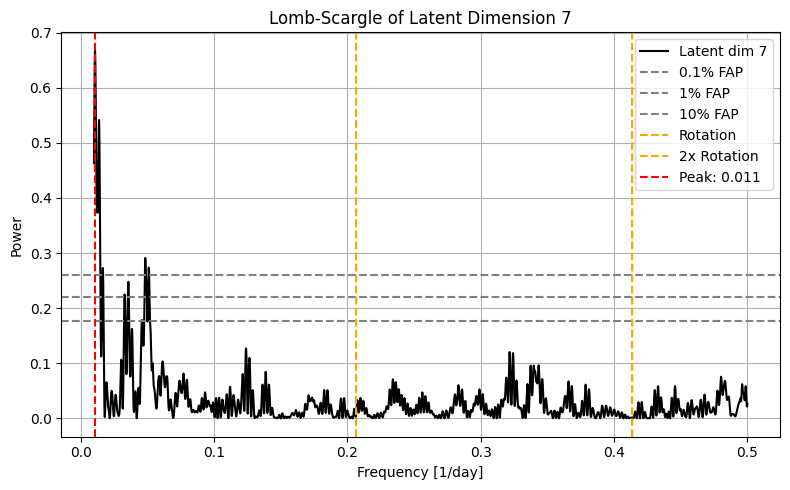

Latent dim 7: Best period = 92.729 days


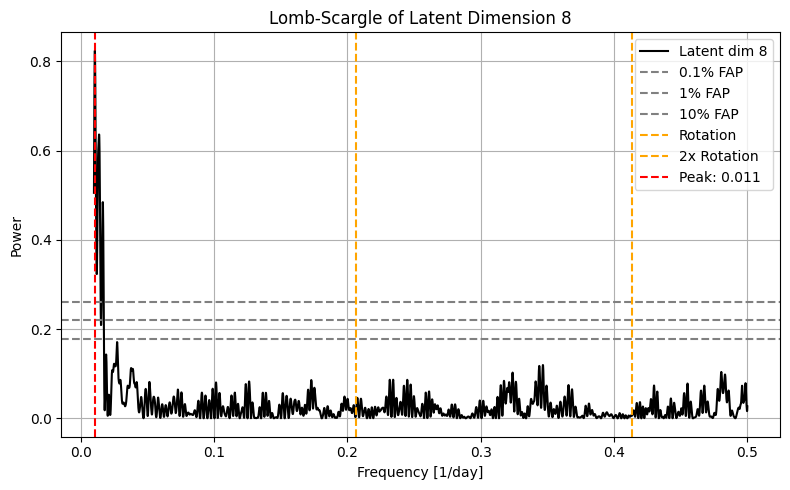

Latent dim 8: Best period = 93.579 days


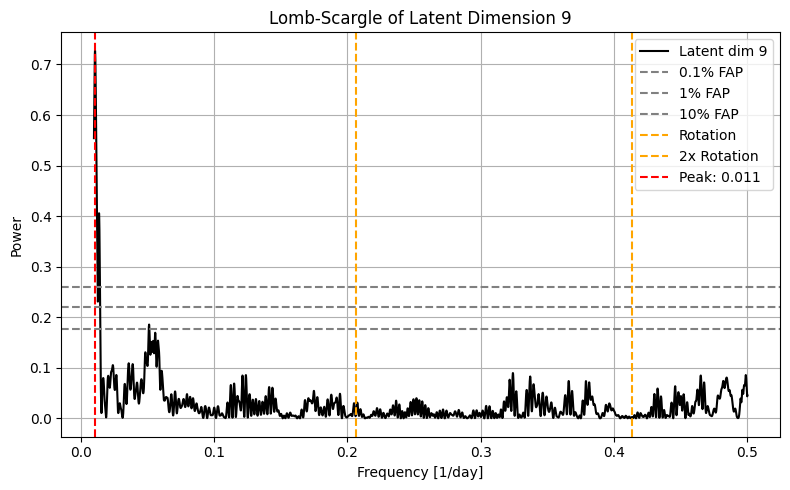

Latent dim 9: Best period = 92.729 days


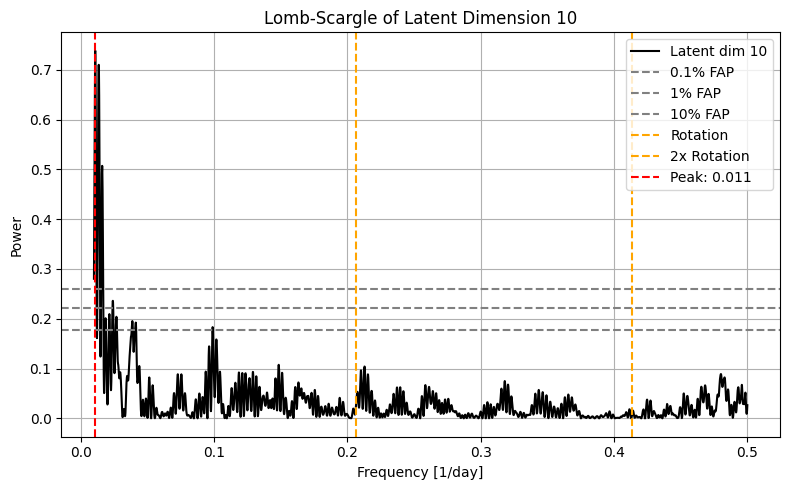

Latent dim 10: Best period = 91.073 days


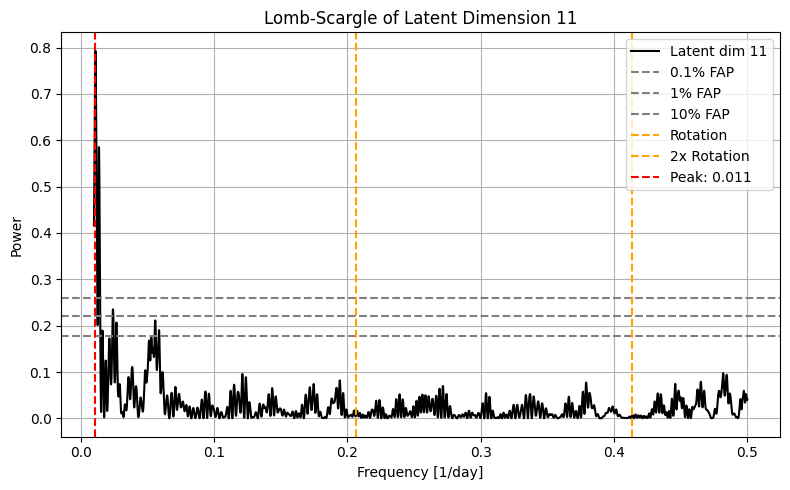

Latent dim 11: Best period = 90.267 days


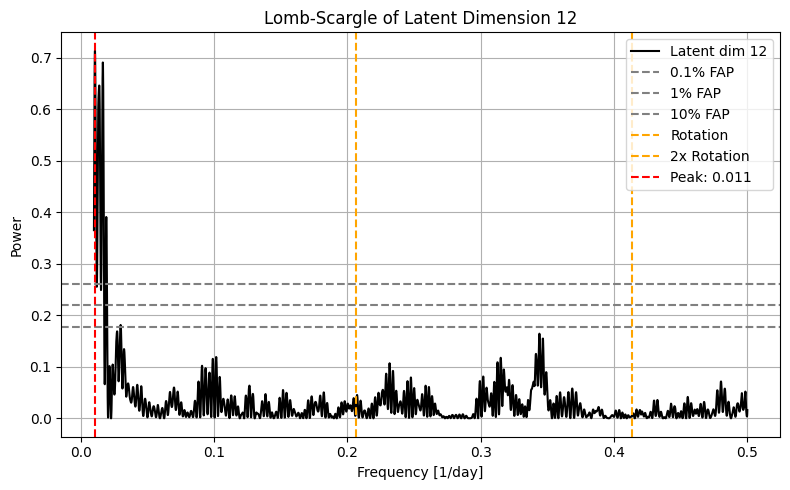

Latent dim 12: Best period = 92.729 days


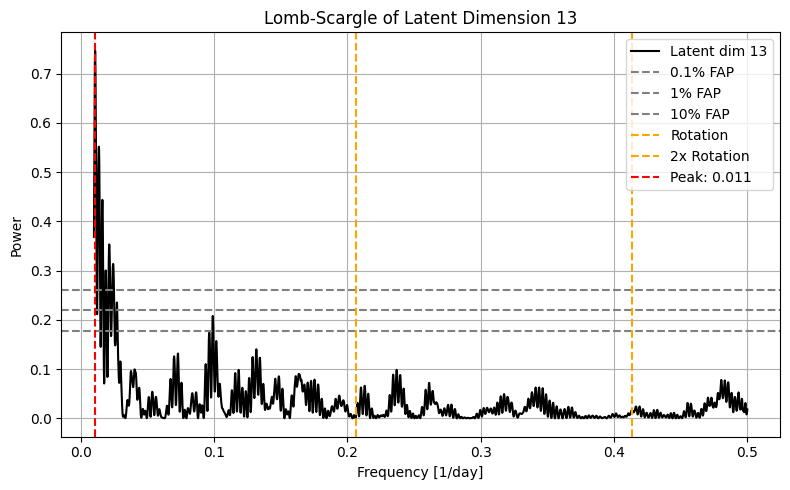

Latent dim 13: Best period = 91.893 days


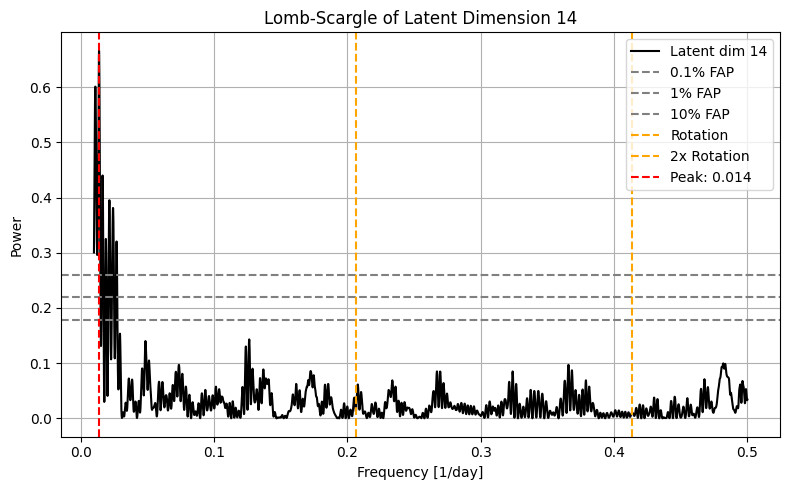

Latent dim 14: Best period = 72.344 days


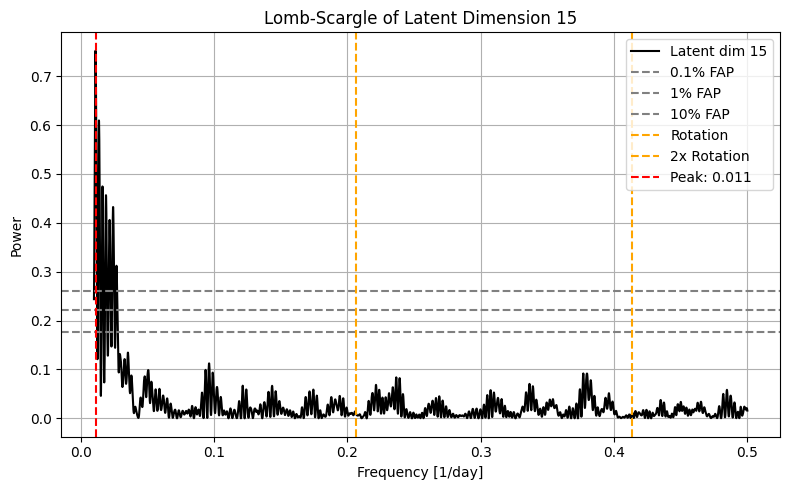

Latent dim 15: Best period = 89.476 days


In [37]:
time = meta["BJD"].values
plot_lomb_scargle(z_mean, time, output_dir=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/lomb_scargle")

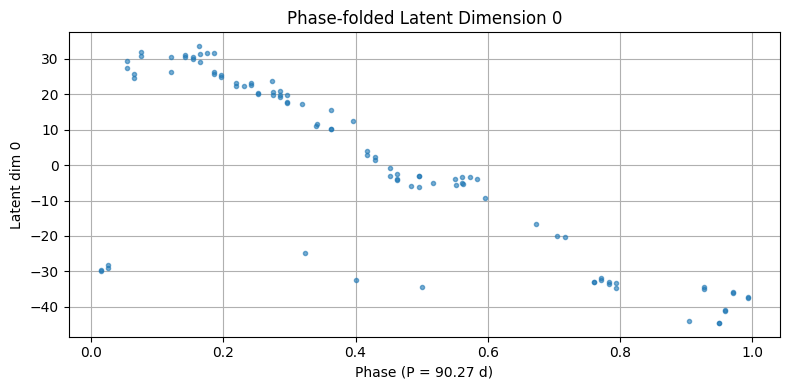

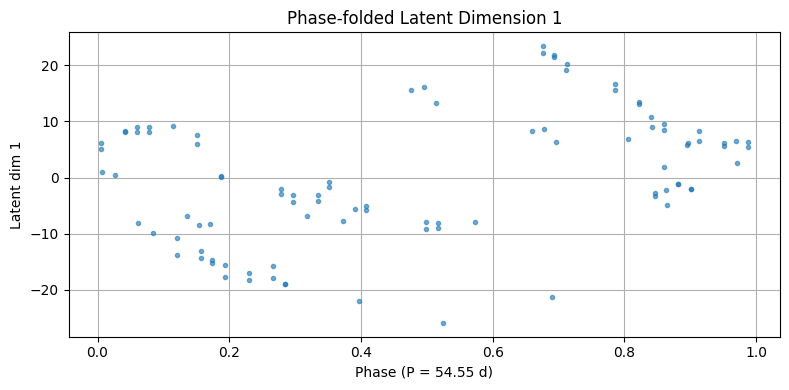

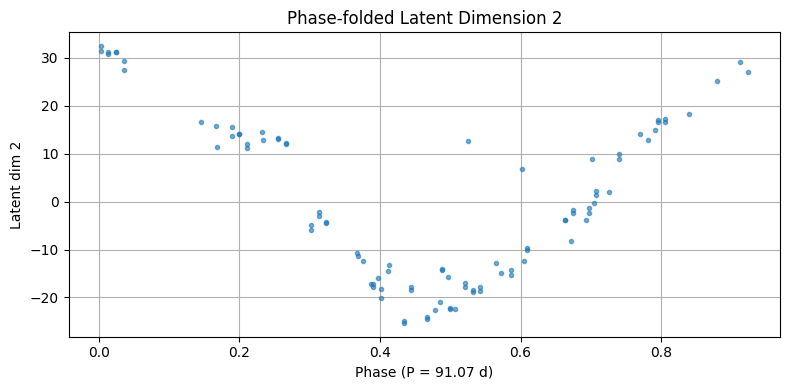

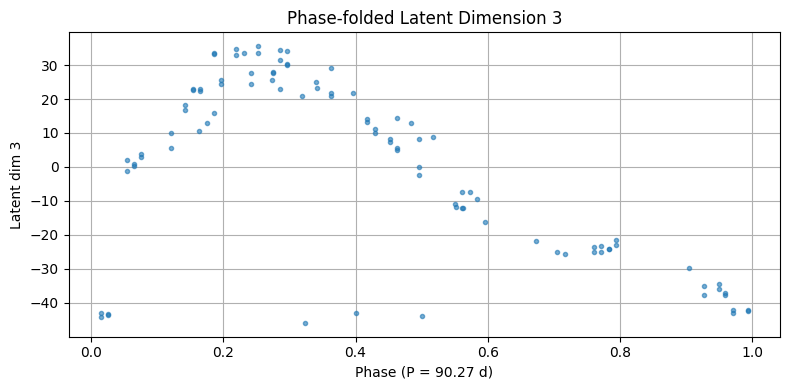

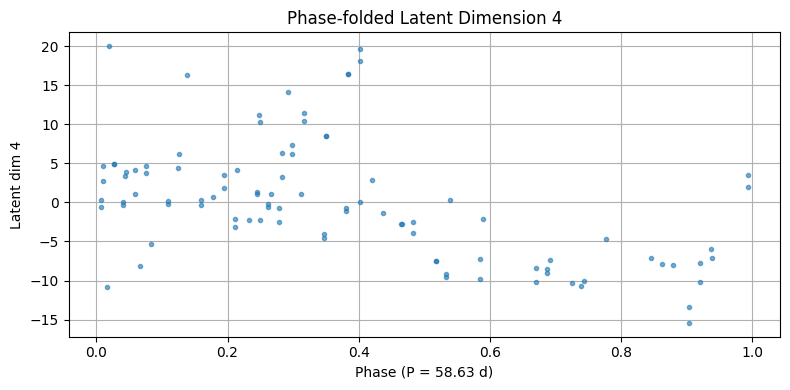

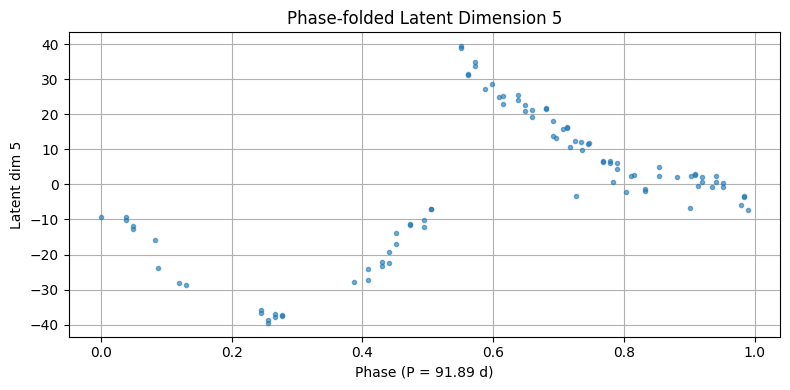

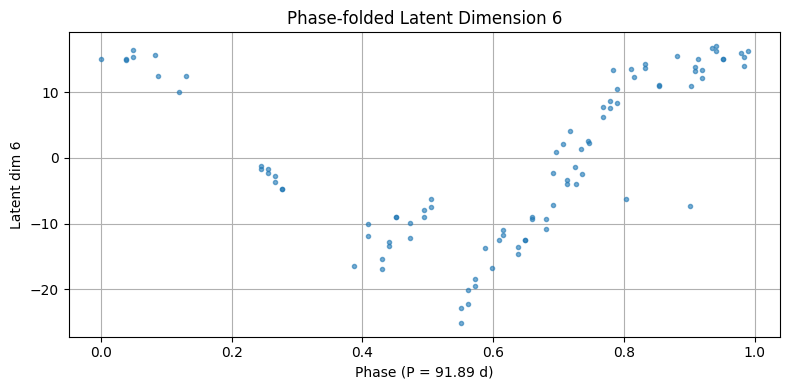

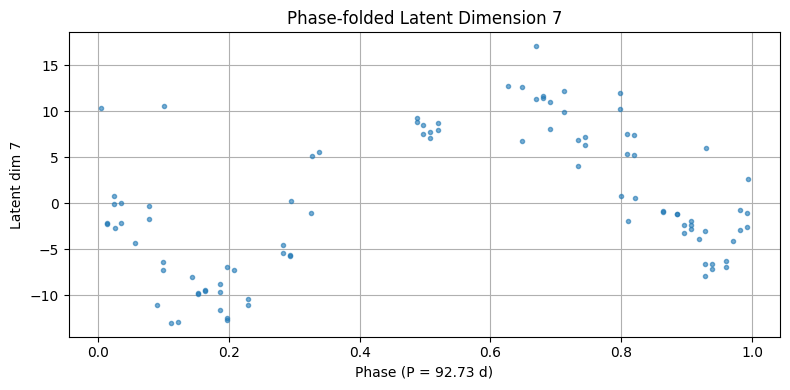

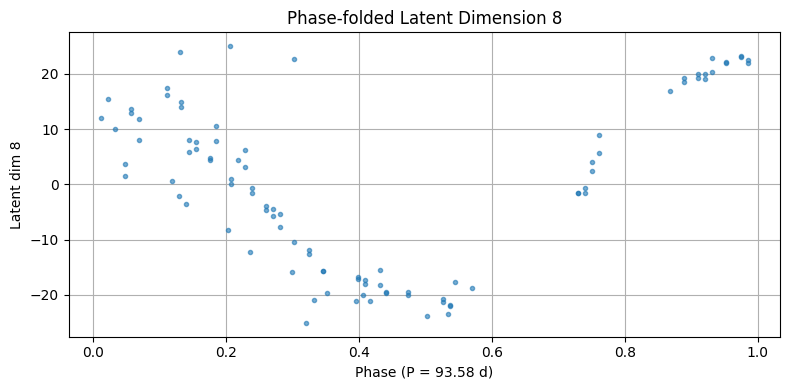

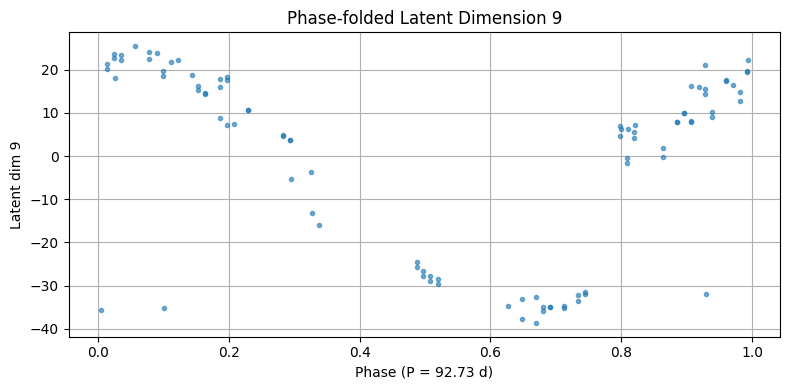

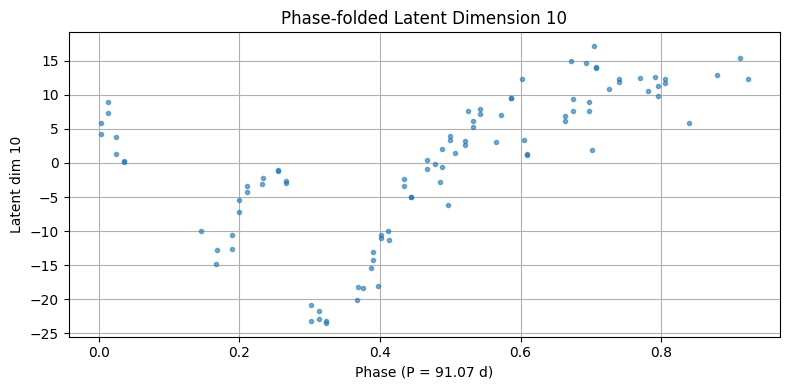

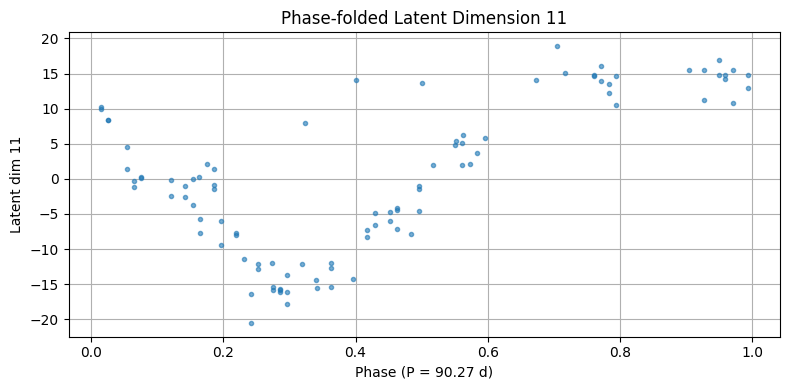

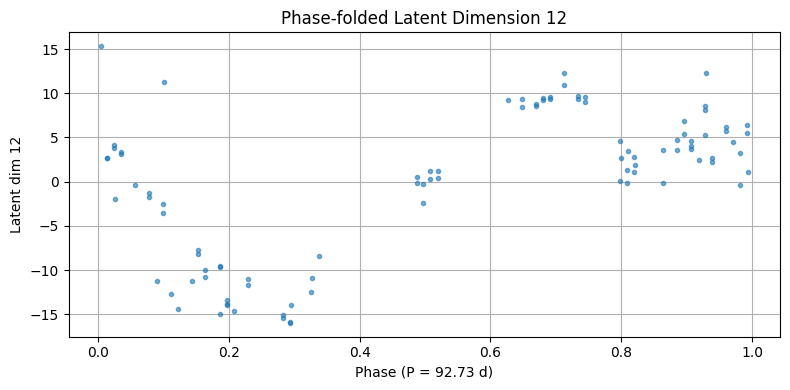

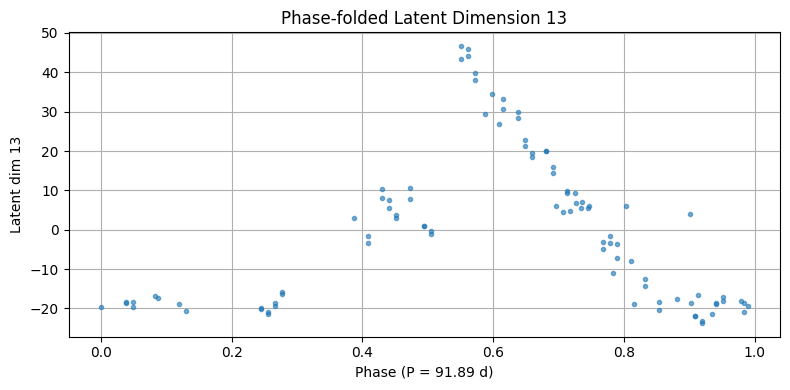

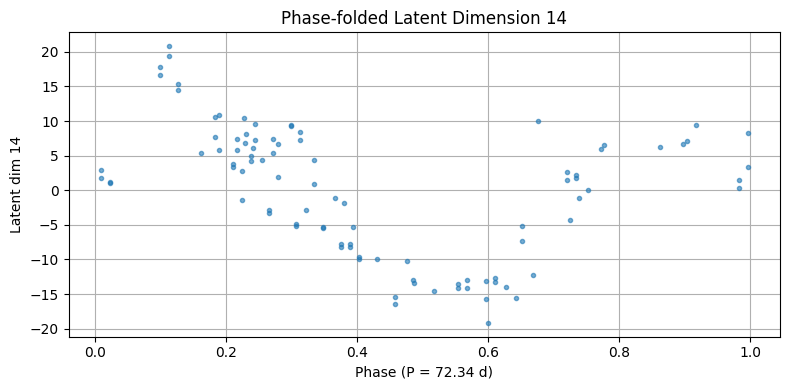

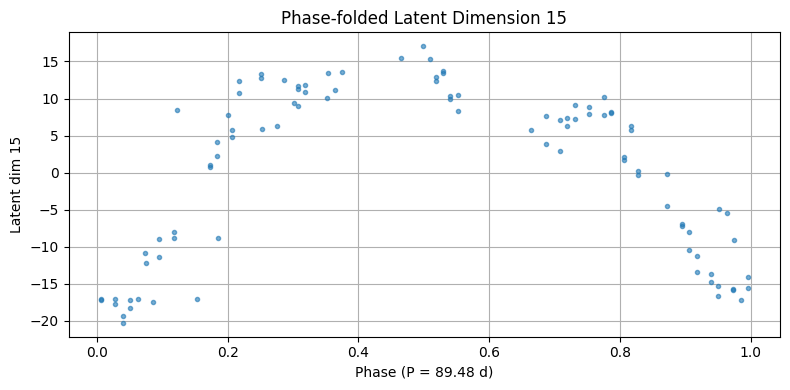

Phase-folded plots saved to: outputs/models/vae_full/v_43/plots/phase_folded_latent_dims


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import os
from astropy.timeseries import LombScargle

def phase_fold(time, signal, period):
    phase = (time % period) / period
    sorted_indices = np.argsort(phase)
    return phase[sorted_indices], signal[sorted_indices]

def plot_phase_folded_latent_dims(z_mean, bjd, output_dir, n_bins=100):
    os.makedirs(output_dir, exist_ok=True)
    frequencies = np.linspace(1/100, 0.5, 5000)

    for i in range(z_mean.shape[1]):
        signal = z_mean[:, i] - np.mean(z_mean[:, i])
        ls = LombScargle(bjd, signal)
        power = ls.power(frequencies)
        best_freq = frequencies[np.argmax(power)]
        best_period = 1 / best_freq

        phase, folded = phase_fold(bjd, signal, best_period)

        plt.figure(figsize=(8, 4))
        plt.plot(phase, folded, 'o', markersize=3, alpha=0.6)
        plt.xlabel(f"Phase (P = {best_period:.2f} d)")
        plt.ylabel(f"Latent dim {i}")
        plt.title(f"Phase-folded Latent Dimension {i}")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"latent_dim_{i}_phasefold.png"), dpi=150)
        plt.show()
        plt.close()

    print(f"Phase-folded plots saved to: {output_dir}")

output_dir = f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/phase_folded_latent_dims"

plot_phase_folded_latent_dims(z_mean, meta["BJD"].values, output_dir)

### 11. Plot Reconstructions

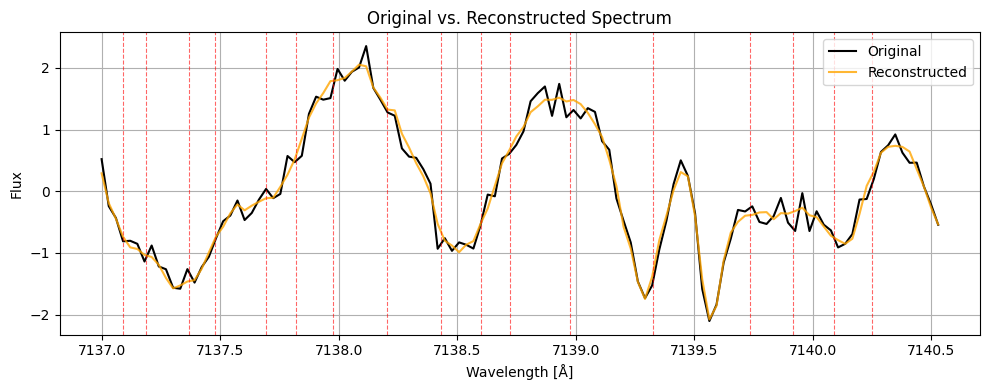

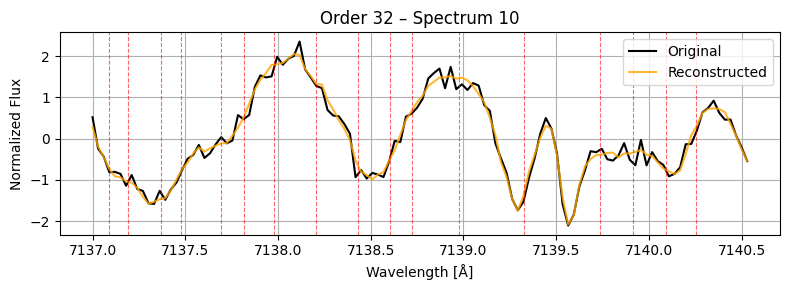

In [38]:
vis_a_files = load_file_list()

x_input_original = scaler.inverse_transform(X_scaled_original)
x_reconstructed = scaler.inverse_transform(x_pred)

if USE_CROPPED_ORDER:
    with open("../outputs/preprocessed/cropped_order32/with_rv_unit.pkl", "rb") as f:
        cropped_data = pickle.load(f)
    wave_data = cropped_data["wavelengths"] 
    wavelengths_stacked = wave_data[ORDER_SELECTION[0]] 
else:
    with fits.open(vis_a_files[0]) as hdul:
        wave_data_raw = hdul["WAVE"].data
    wave_data = {order: wave_data_raw[order] for order in ORDER_SELECTION}
    wavelengths_stacked = np.hstack([wave_data[order] for order in ORDER_SELECTION])

plot_reconstruction(
    wavelengths_stacked,
    x_input_original[10],
    x_reconstructed[10],
    save_path=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/reconstruction/full_spec.png", 
    mask_lines=mask_df["lambda"].values
)

plot_order_reconstructions(
    wave_data,
    x_input_original,
    x_reconstructed,
    ORDER_SELECTION,
    i=10,
    save_dir=f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/reconstruction/by_order",
    mask_lines=mask_df["lambda"].values
)

### 12. Latent Variance Inspections

In a VAE, the variance (or log-variance) controls how uncertain the model is about the latent representation of each input. 

We're modeling stellar spectra with rotational modulation and activity-induced line asymmetries.

Variations in the mean capture the central trend of features learned.

But variations in the log-variance might capture:

- Spectral observations that are less confidently encoded - e.g., during flaring or when spot-induced distortions are stronger.

- Epochs of higher activity or variability, leading to less compressible representations.

- Subtle physical regimes the model struggles to compress linearly.

**Standard Deviation:**

In [39]:
z_sigma = np.exp(z_log_sigma)

**Variance:**

In [40]:
z_variance = np.exp(2 * z_log_sigma)

New file directory:

In [41]:
plot_dir_v = f"outputs/models/vae_full/v_{MODEL_VERSION}/plots/variance"
os.makedirs(plot_dir_v, exist_ok=True)

#### Latent Variance vs. BJD

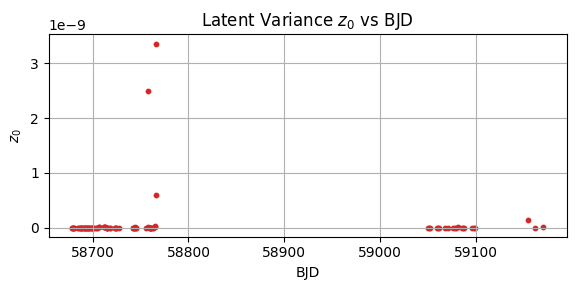

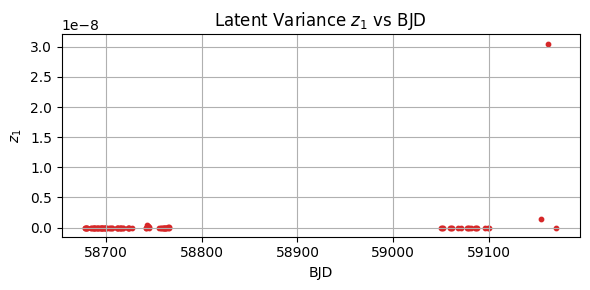

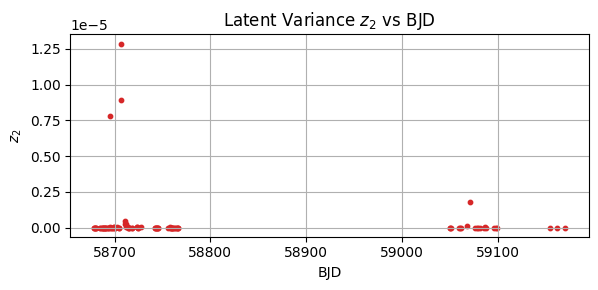

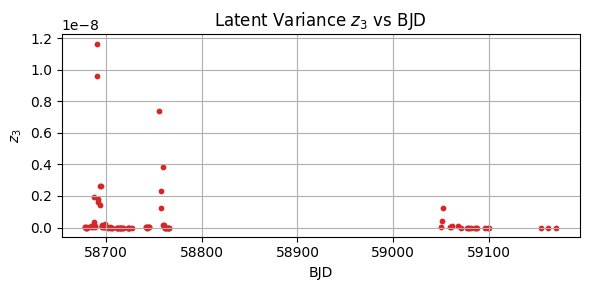

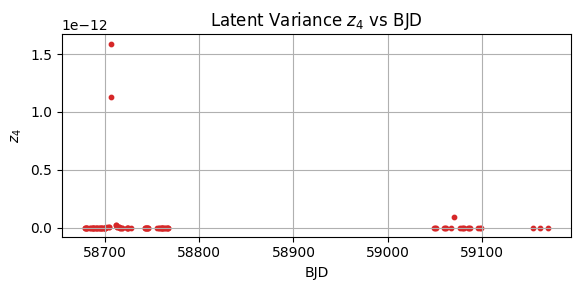

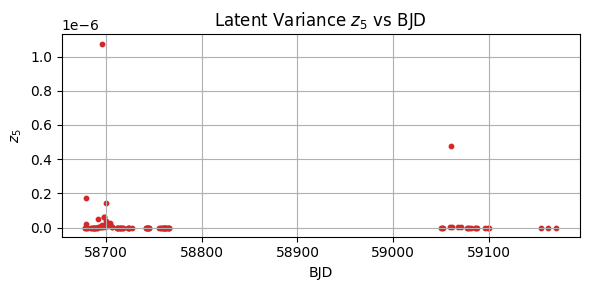

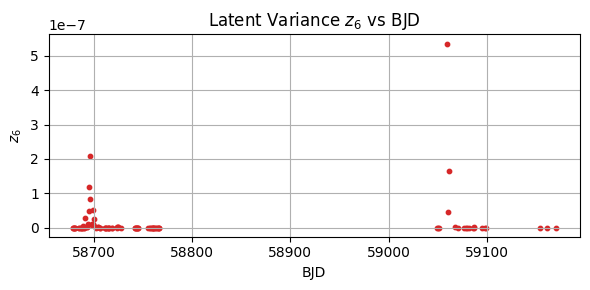

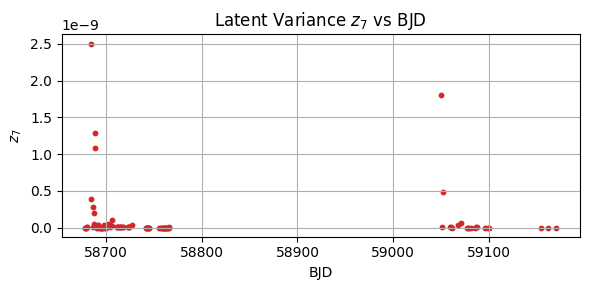

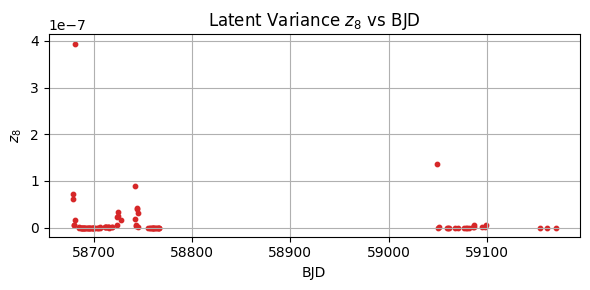

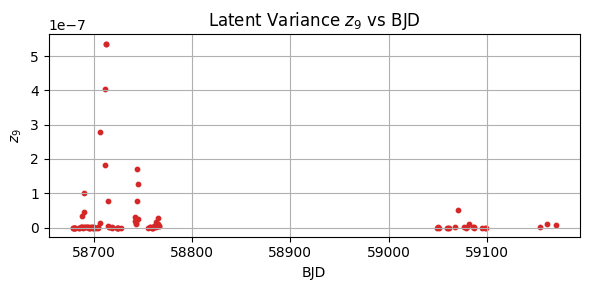

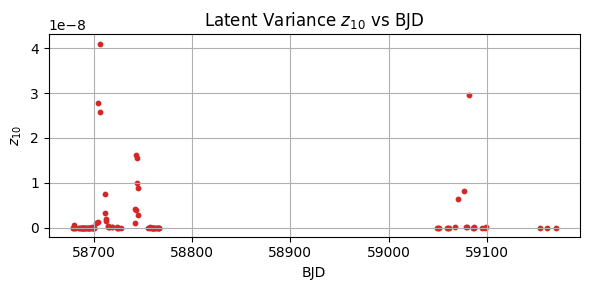

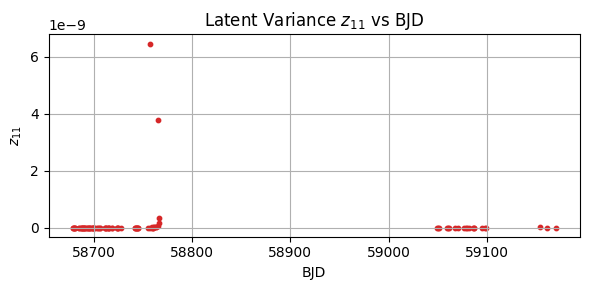

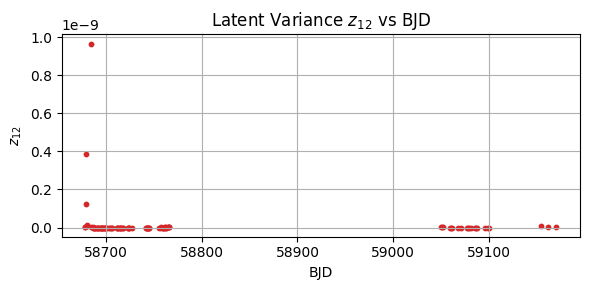

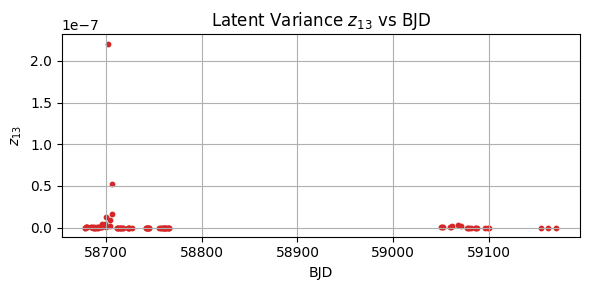

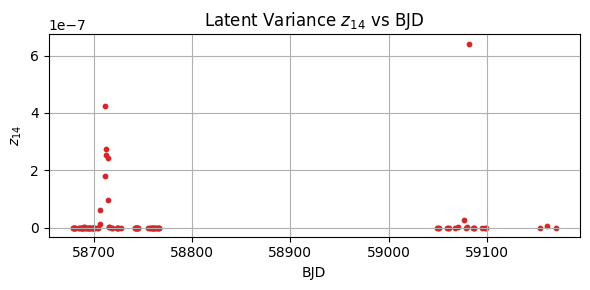

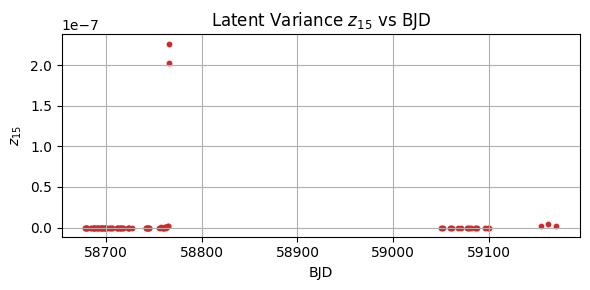

In [42]:
for i in range(n_dims):
    plt.figure(figsize=(6, 3))
    plt.scatter(meta["BJD"], z_variance[:, i], s=10, c='tab:red')
    plt.title(f"Latent Variance $z_{{{i}}}$ vs BJD")
    plt.xlabel("BJD")
    plt.ylabel(f"$z_{{{i}}}$")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{plot_dir_v}/z_var_{i}_vs_BJD.png")
    plt.show()
    plt.close()

#### **UMAPs**

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


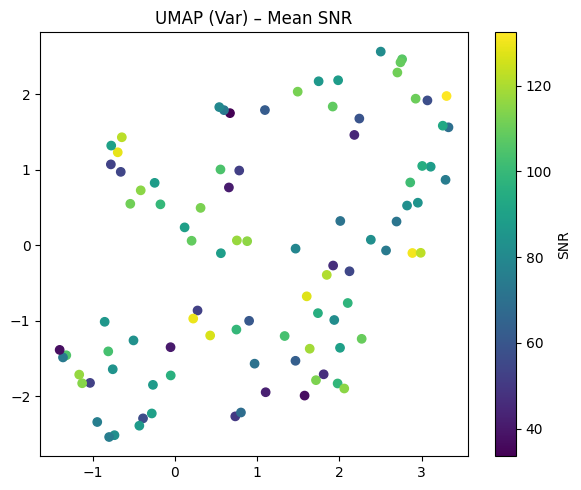

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


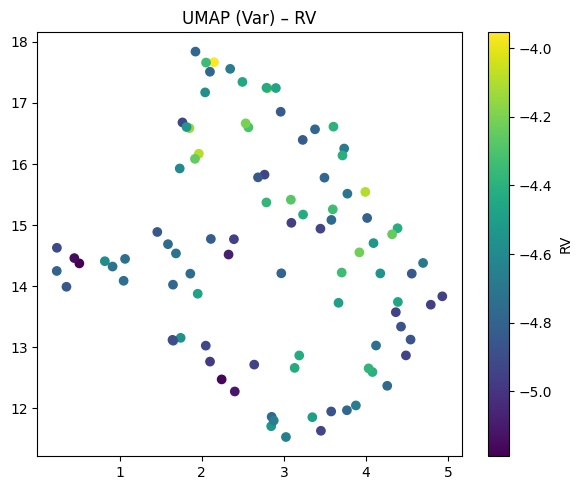

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


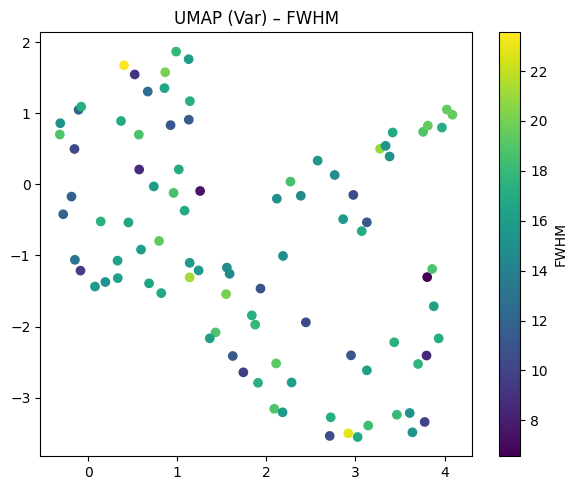

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


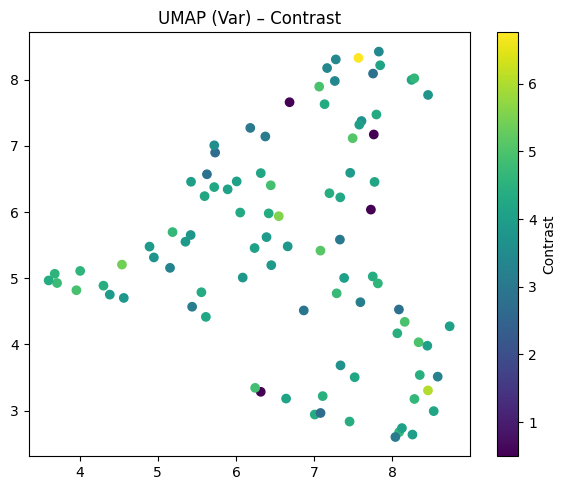

/home/ice/.cache/pypoetry/virtualenvs/exoplanet-autoencoder-LTlp-vC0-py3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


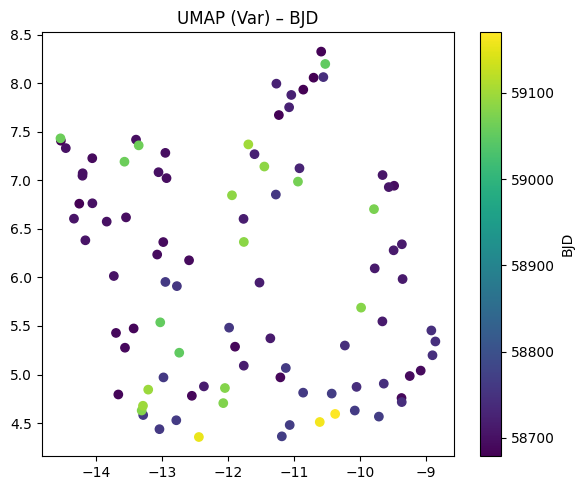

In [43]:
plot_umap(z_variance, meta["SNR_mean"], title="UMAP (Var) – Mean SNR", color_label="SNR",
          save_path=f"{plot_dir_v}/UMAP/SNR_mean.png")

plot_umap(z_variance, meta["RV"], title="UMAP (Var) – RV", color_label="RV",
          save_path=f"{plot_dir_v}/UMAP/RV.png")

plot_umap(z_variance, meta["FWHM"], title="UMAP (Var) – FWHM", color_label="FWHM",
          save_path=f"{plot_dir_v}/UMAP/FWHM.png")

plot_umap(z_variance, meta["CONTRAST"], title="UMAP (Var) – Contrast", color_label="Contrast",
          save_path=f"{plot_dir_v}/UMAP/Contrast.png")

plot_umap(z_variance, meta["BJD"], title="UMAP (Var) – BJD", color_label="BJD",
          save_path=f"{plot_dir_v}/UMAP/BJD.png")

#### **Lomb Scargle**

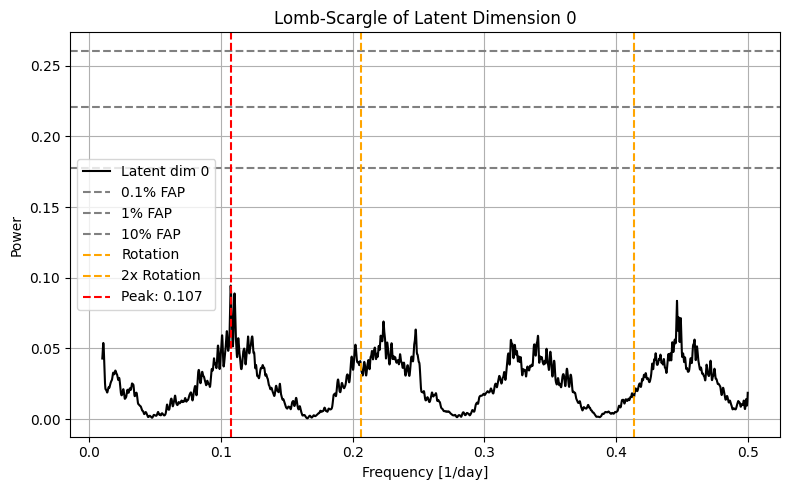

Latent dim 0: Best period = 9.308 days


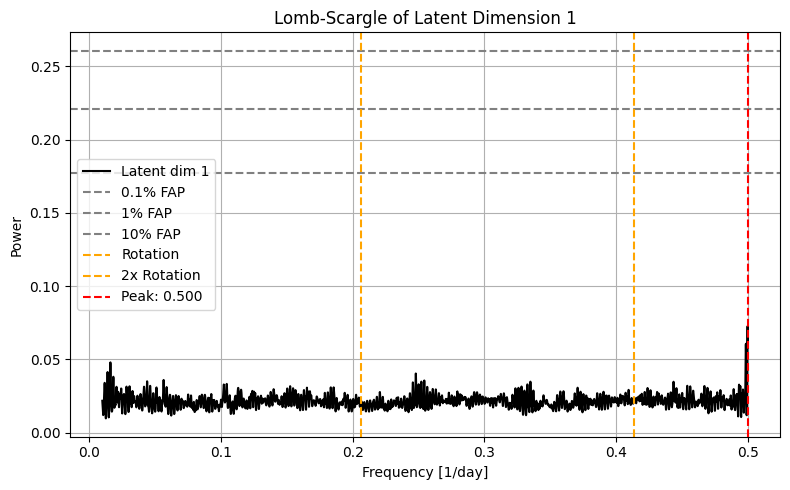

Latent dim 1: Best period = 2.000 days


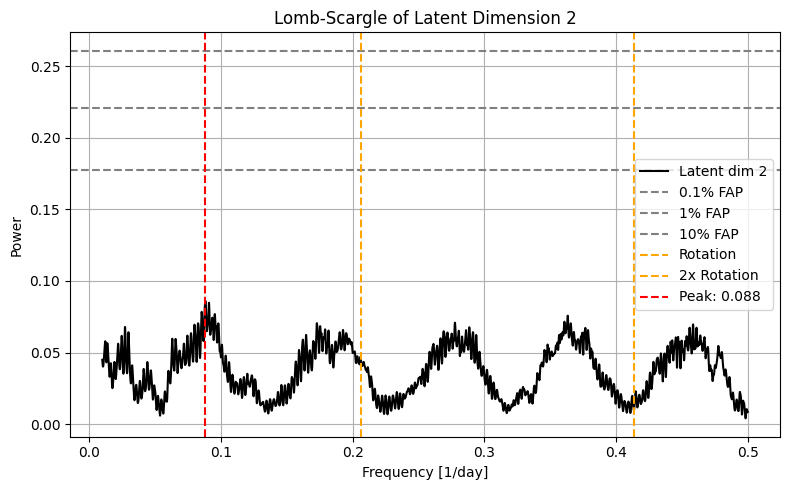

Latent dim 2: Best period = 11.323 days


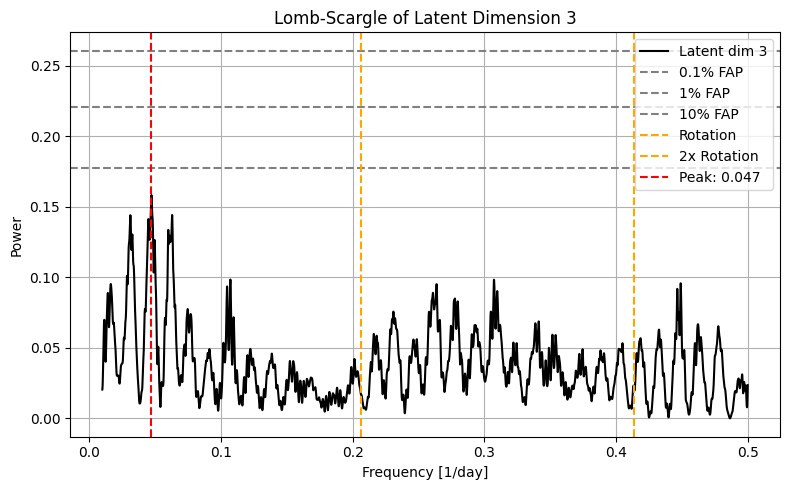

Latent dim 3: Best period = 21.165 days


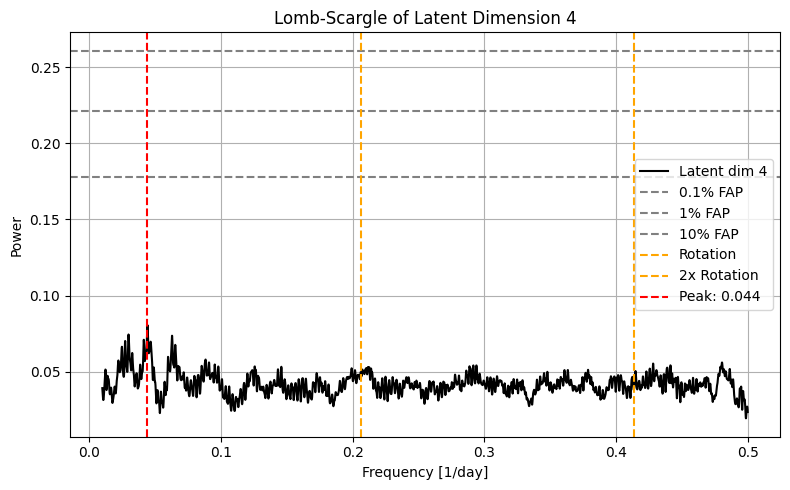

Latent dim 4: Best period = 22.570 days


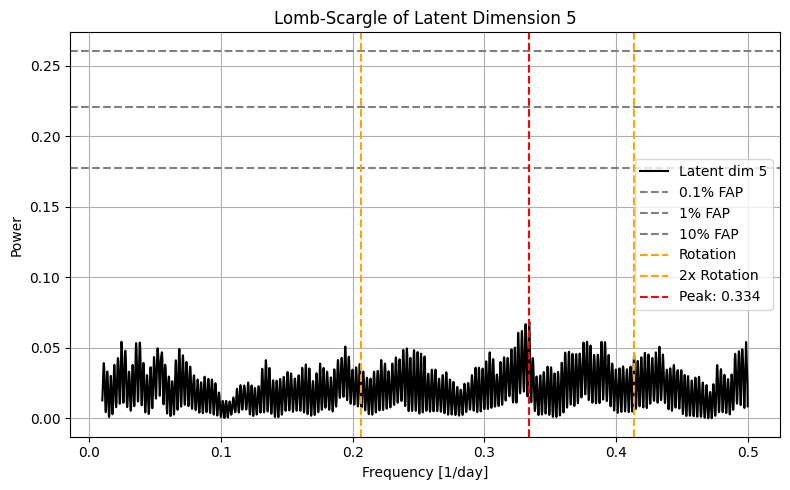

Latent dim 5: Best period = 2.993 days


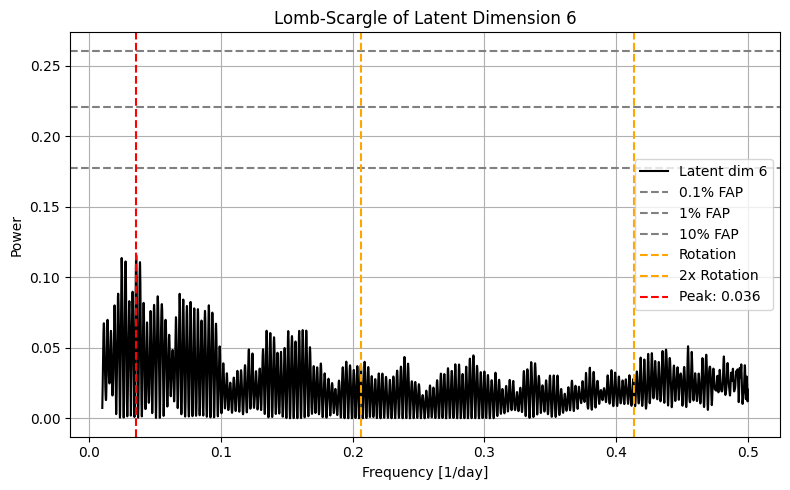

Latent dim 6: Best period = 27.949 days


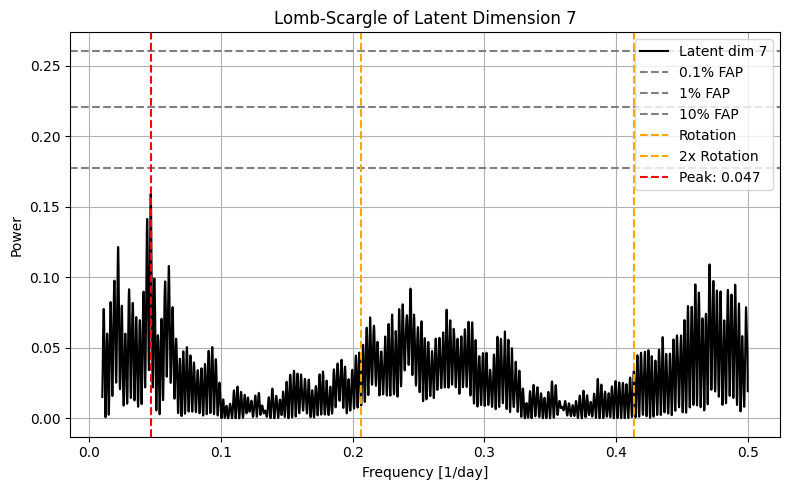

Latent dim 7: Best period = 21.387 days


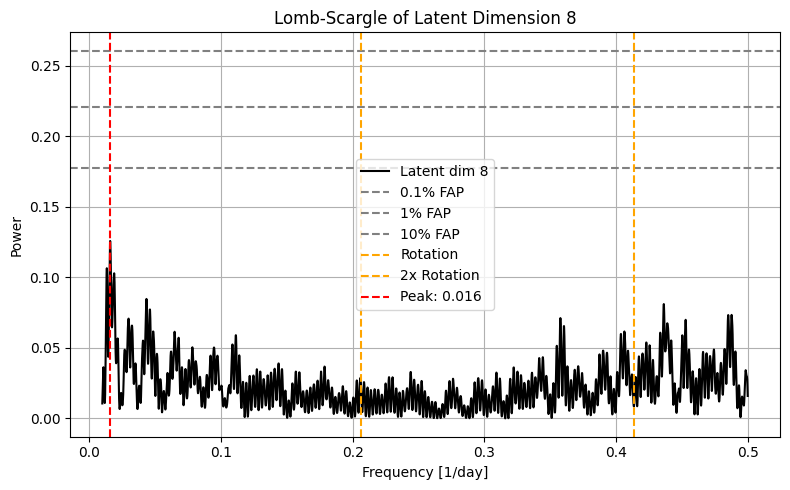

Latent dim 8: Best period = 62.581 days


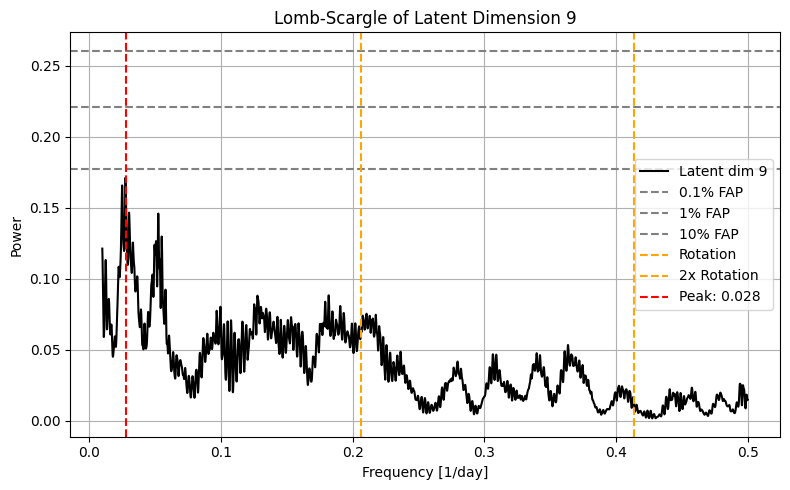

Latent dim 9: Best period = 36.175 days


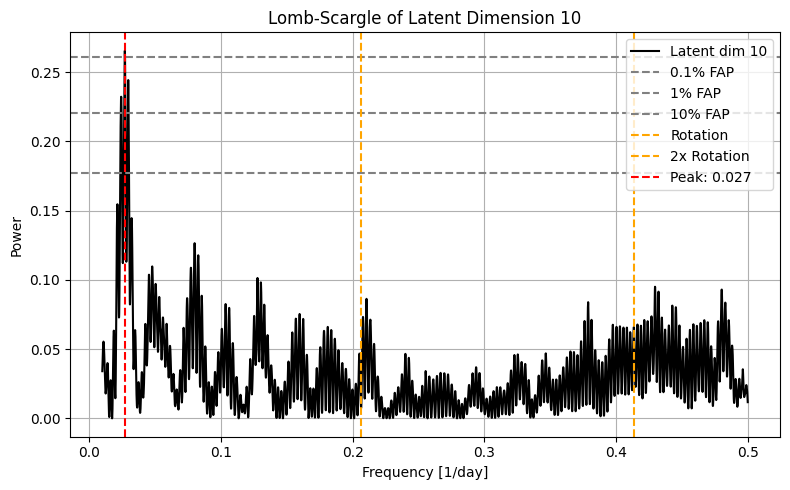

Latent dim 10: Best period = 36.828 days


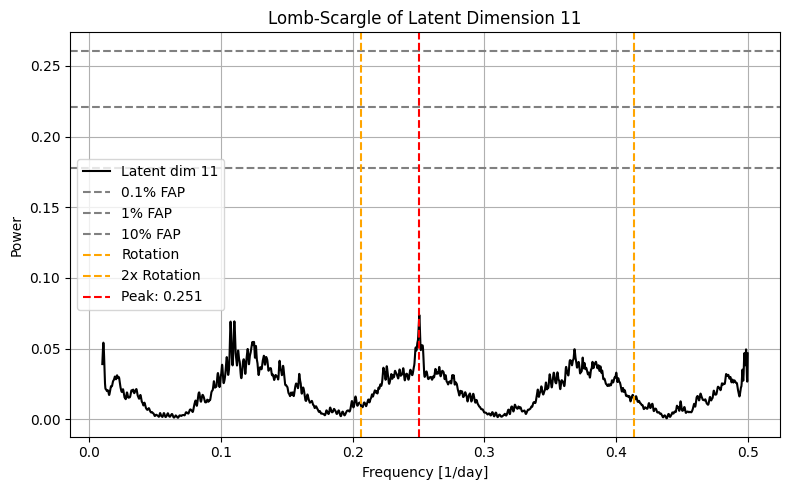

Latent dim 11: Best period = 3.990 days


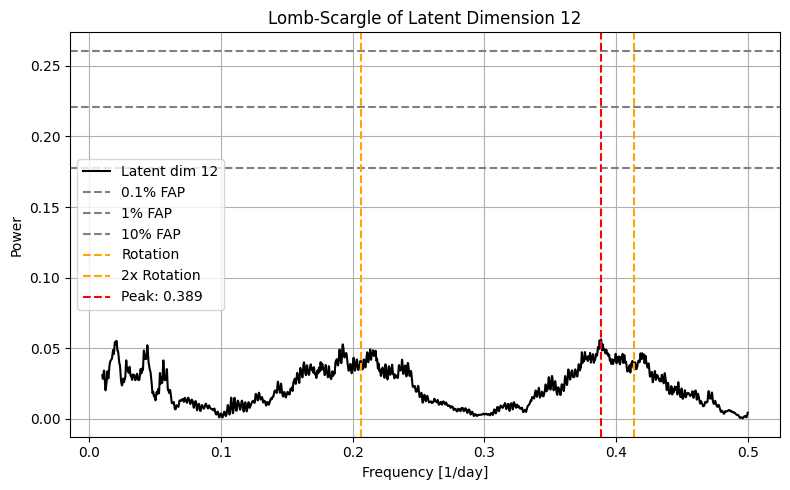

Latent dim 12: Best period = 2.572 days


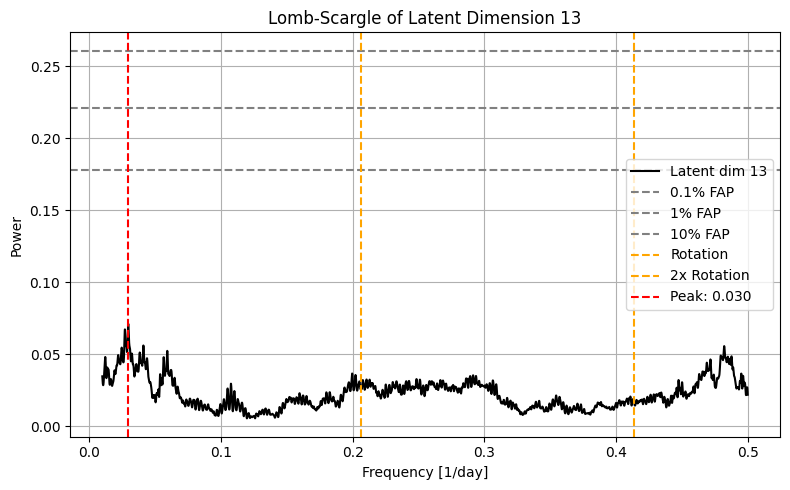

Latent dim 13: Best period = 33.668 days


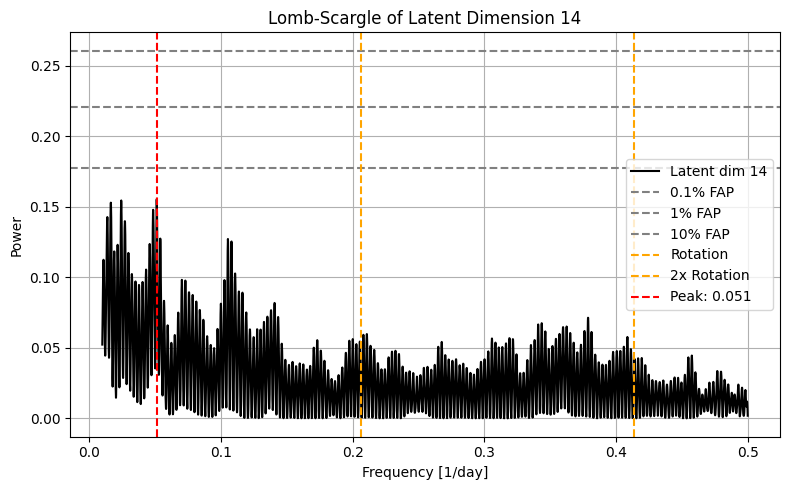

Latent dim 14: Best period = 19.506 days


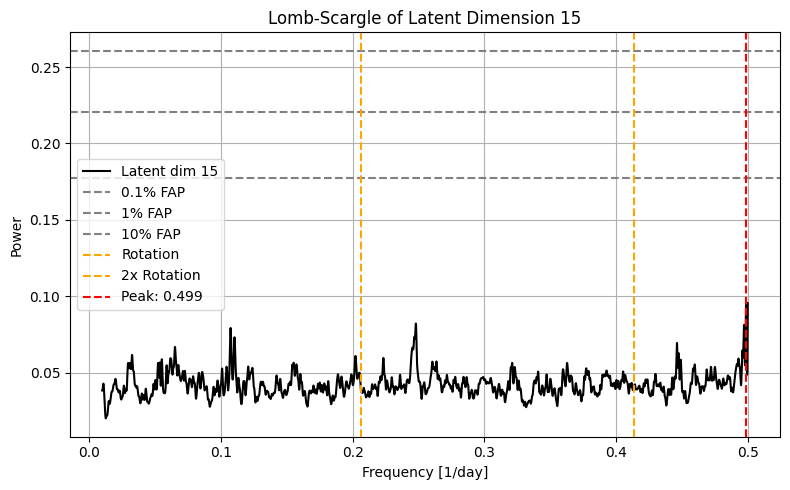

Latent dim 15: Best period = 2.005 days


In [44]:
plot_lomb_scargle(z_variance, time, output_dir=f"{plot_dir_v}/lomb_scargle")

---

**Clear GPU memory:**

In [45]:
tf.keras.backend.clear_session()
gc.collect()
try:
    cuda.select_device(0)
    cuda.close()
except:
    pass

print("GPU memory cleared.")

GPU memory cleared.
